# 🌴🧑🏻‍💻 Project 2: Workforce Analytics 👩🏻‍💻⚡
##### Author: Mike Ee, [mikeee.co](https://mikeee.co)

Business Question
> Will our workers return to physical office spaces?

## Table of Contents

1. [Background](#background)
2. [Load data](#data)
3. [Exploratory Data Analysis](#eda)
4. [Methodology](#methodology)
5. [Predictive Modelling](#modelling)
6. [Conclusion](#conclusion)
7. [References & Acknowledgements](#ref)

<a id="background"></a>

## 1. Background

In a business organisation, internal stakeholders such as C-suite executives, HR managers as well as Facilities Management would regularly need to discuss manpower issues. <b>Organisations must quantify worker compliance versus disruption before committing capital</b>. Through predictive modelling, decisions regarding developing contemporary hiring expectations (e.g. embracing hybrid work, re-defining workplace culture, team building and work-life balance) along with capital resourcing expenditure, can be backed by employee data. 

<u>About the dataset</u> The Global Survey of Working Arrangements (G-SWA) is a recurring, internationally harmonized study tracking remote work trends, productivity, employee preferences, and employer policies across dozens of countries worldwide. Within this project, the 2022 wave of the dataset—comprising over 36,000 responses across 34 variables—is utilized to build a multi-class predictive model that forecasts employee behaviors (Return-to-Office compliance, WFH-seeking, or flight risk) to optimize corporate real estate and retention strategies.

<a id="data"></a>
## 2. Load data

In [2]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (classification_report, balanced_accuracy_score,
                             f1_score, ConfusionMatrixDisplay, roc_auc_score,
                             roc_curve, auc)

from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_score
import itertools

from sklearn.preprocessing import label_binarize

from sklearn.pipeline import Pipeline

!pip install mord -q
import mord

In [3]:
# Styling
from matplotlib import font_manager
import matplotlib.patches as mpatches

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "font-inter", "-q"], check=False)

font_manager._load_fontmanager(try_read_cache=False)

DARK, FG, MUTED = "#121214", "#EAEAEA", "#B8B8B8"
mpl.rcParams.update({
    "figure.facecolor": DARK, "axes.facecolor": DARK, "savefig.facecolor": DARK,
    "text.color": FG, "axes.titlecolor": "#F5F5F5", "axes.labelcolor": FG,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": "#3A3A3A", "grid.color": "#242428",
    # ── Font ──
    "font.family": "Inter",
    "font.weight": "regular",          # Inter ships Regular, Medium, SemiBold, Bold
})
sns.set_context("talk")                

# Rocket palette
rocket = sns.color_palette("rocket", as_cmap=True)

# Class colours: brightest = most business-urgent (Quit glows, Comply recedes)
CLS       = {"Quit": rocket(0.80), "WFH-seek": rocket(0.55), "Comply": rocket(0.28)}
CLS_ORDER = ["Quit", "WFH-seek", "Comply"]

ACCENT  = rocket(0.70)     # #f3714d coral — single-series bars & lines
RISK    = rocket(0.70)     # diverging bars: pushes AWAY from Comply
COMPLY  = rocket(0.35)     # diverging bars: pushes TOWARD Comply (deep magenta)
NEUTRAL = "#8A8A92"        # baseline model / reference lines / de-emphasis

# Model comparison: brightness ranks performance — brightest = winner
MODEL_COLORS = {
    "Baseline (majority)": NEUTRAL,
    "Naive Bayes":         rocket(0.38),
    "KNN (k=15)":          rocket(0.55),
    "Logistic Regression": rocket(0.75),
}

# Diverging cmap for the correlation heatmap: cool grey (−) → near-black
# centre (zero blends into the dark bg) → rocket crimson/salmon (+)
from matplotlib.colors import LinearSegmentedColormap
ROCKET_DIV = LinearSegmentedColormap.from_list(
    "rocket_div", ["#7C8DA6", "#1B1B1F", "#DB2946", "#F69C73"]
)

In [4]:
gswa = pd.read_csv("G-SWA.csv")

### 2.1 Pre-EDA

In [5]:
gswa

,idnum,original_country,wave,country,originalcountry,regionname,gender,agegroups,education,industry_job,...,return_office,ever_WFH,commute_time_hs,deaths_pc,LSI,reg_deaths_pc,subn_LSI,oxf_LSI,gdppc2019,mask
0,1,Australia,1,Australia 1,27,Victoria,Male,50-59,Secondary,Professional & Business Services,...,NaN,100,0.0,0,12,0.0,9.0,1049,58781,8
1,2,Australia,1,Australia 1,27,Queensland,Male,40-49,Tertiary,Professional & Business Services,...,NaN,100,2.0,0,12,0.0,8.0,1049,58781,8
2,3,Australia,1,Australia 1,27,Victoria,Male,30-39,Graduate,Professional & Business Services,...,NaN,100,2.0,0,12,0.0,9.0,1049,58781,8
3,4,Australia,1,Australia 1,27,Victoria,Male,40-49,Graduate,Health Care & Social Assistance,...,NaN,0,1.0,0,12,0.0,9.0,1049,58781,8
4,5,Australia,1,Australia 1,27,Victoria,Male,20-29,Secondary,Other,...,NaN,0,0.0,0,12,0.0,9.0,1049,58781,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36073,917,Ukraine,2,Ukraine 2,17,NaN,Female,20-29,Graduate,Utilities,...,Comply and return to worksite,0,1.0,0,16,NaN,NaN,1391,2426,15
36074,918,Ukraine,2,Ukraine 2,17,NaN,Female,20-29,Secondary,Retail Trade,...,Comply and return to worksite,100,1.0,0,16,NaN,NaN,1391,2426,15
36075,919,Ukraine,2,Ukraine 2,17,NaN,Female,40-49,Secondary,Health Care & Social Assistance,...,Comply and return to worksite,100,6.0,0,16,NaN,NaN,1391,2426,15
36076,920,Ukraine,2,Ukraine 2,17,NaN,Female,20-29,Tertiary,Finance or Insurance,...,Comply and return to worksite,100,1.0,0,16,NaN,NaN,1391,2426,15


#### 2.1.1 Inspect Null Values
Quick look at `return_office`: null values and relationship to survey runs

In [6]:
# PRE-CHECK 1: NaN columns for 'return_office' against 'wave' and 'country'
gswa.groupby('wave')['return_office'].apply(lambda x: x.isnull().mean()*100)
gswa.groupby('country')['return_office'].apply(lambda x: x.isnull().mean()*100)

country
Australia 1      100.0
Australia 2        0.0
Austria 2          0.0
Brazil 2           0.0
Canada 2           0.0
China 1          100.0
China 2            0.0
Egypt 1          100.0
France 1         100.0
France 2           0.0
Germany 1        100.0
Germany 2          0.0
Greece 1         100.0
Greece 2           0.0
Hungary 1        100.0
Hungary 2          0.0
India 2            0.0
Italy 2            0.0
Japan 2            0.0
Korea 2            0.0
Malaysia 2         0.0
Netherlands 1    100.0
Netherlands 2      0.0
Poland 1         100.0
Poland 2           0.0
Russia 2           0.0
Serbia 1         100.0
Singapore 2        0.0
Spain 2            0.0
Sweden 1         100.0
Sweden 2           0.0
Taiwan 2           0.0
Turkey 1         100.0
Turkey 2           0.0
UK 1             100.0
UK 2               0.0
USA 1            100.0
USA 2              0.0
Ukraine 1        100.0
Ukraine 2          0.0
Name: return_office, dtype: float64

#### 2.1.2 Profiling
Profile data types to get sense of cleaning required

In [7]:
# PRE-CHECK 2: Determine all avail column names and their dtypes
gswa.dtypes

idnum                       int64
original_country           object
wave                        int64
country                    object
originalcountry             int64
regionname                 object
gender                     object
agegroups                  object
education                  object
industry_job               object
age                         int64
tertiary                    int64
graduate                    int64
married                   float64
male                        int64
with_kids                 float64
male_with_kids            float64
n_work_home               float64
daysemployer_work_home    float64
daysemployee_work_home      int64
value_WFH_rawpercent25      int64
commuting_time              int64
WFH_expectations1         float64
WFHperceptions              int64
return_office              object
ever_WFH                    int64
commute_time_hs           float64
deaths_pc                   int64
LSI                         int64
reg_deaths_pc 

#### 2.1.3 Check for longitudinal nature
Consider possibility of trend analysis by looking at `idnum`

In [8]:
# PRE-CHECK 3: Quick look at 'idnum': how many distinct IDs exist 
print("unique idnum overall:", gswa["idnum"].nunique())   
print("rows total:", len(gswa))

unique idnum overall: 1314
rows total: 36078


#### 2.1.4 Observations
* From Pre-check 1, the `return_office` column only appears in Wave 2 (2022 survey). <b>To focus on Wave 2 only</b> for predictive modeling.
* From Pre-check 2, while it is good that most columns are numeric, should still check for null values. To change `return_office` column values to numeric.
* From Pre-check 3, while there are 1314 unique ID numbers out of 36078 rows. Perhaps the same ID number is used for each country's survey entries? <i>See 2.2.2 for further inspection.</i>

### 2.2 Ideation Phase 

#### 2.2.1 Determine target column
To confirm `return_office` is target variable, and how many classes (i.e. binary or multi-class)?


In [9]:
# CHECK 1: What kind of classification for Wave 2's 'return_office'?
w2 = gswa[gswa["wave"] == 2]                  
print(w2["return_office"].value_counts(dropna=False))   

return_office
Comply and return to worksite      19809
 Look for a job to WFH 1-2 days     3585
Quit job                             455
Name: count, dtype: int64


#### 2.2.2 Investigate longitudinal nature
Does a per-person trend exist within Wave 1 to 2, and what sort of differences exist between each wave?


In [10]:
# CHECK 2A: Investigate trend analysis possibility by looking at whether 'idnum's are in Wave 1 and 2

# distinct wave count per id
waves_per_id = gswa.groupby("idnum")["wave"].nunique() 

# ids present in 2+ waves
repeats = waves_per_id[waves_per_id > 1].index    

print("cross-wave idnums:", len(repeats))

cross-wave idnums: 1279


In [11]:
# CHECK 2B: Random check if shared 'idnum' is the same person (Scenario A), not a recycled counter (Scenario B).

# Separate 'idnum' by Wave
ids_w1 = set(gswa.loc[gswa["wave"] == 1, "idnum"])
ids_w2 = set(gswa.loc[gswa["wave"] == 2, "idnum"])

# Ensure single ID appears in both waves
one_id = next(iter(ids_w1 & ids_w2))          

# Stacking other columns that are immutable traits
witnesses = ["idnum", "wave", "gender", "country"]   

# Print only if cross-wave 'idnum' criteria is met, and include immutable traits for comparison
print(gswa.loc[gswa["idnum"] == one_id, witnesses])

       idnum  wave  gender        country
0          1     1    Male    Australia 1
574        1     2    Male    Australia 2
1455       1     2  Female      Austria 2
2112       1     2    Male       Brazil 2
2846       1     2    Male       Canada 2
3741       1     1    Male        China 1
4616       1     2  Female        China 2
5637       1     1    Male        Egypt 1
6141       1     1  Female       France 1
6750       1     2  Female       France 2
7489       1     1  Female      Germany 1
8702       1     2  Female      Germany 2
10015      1     1    Male       Greece 1
10731      1     2    Male       Greece 2
11533      1     1  Female      Hungary 1
12293      1     2  Female      Hungary 2
13154      1     2  Female        India 2
14124      1     2  Female        Italy 2
15054      1     2  Female        Japan 2
15978      1     2  Female        Korea 2
17065      1     2  Female     Malaysia 2
18077      1     1  Female  Netherlands 1
19000      1     2  Female  Nether

#### 2.2.3 Observations
* Dependent variables that might have an impact* on `return_office`
* Can consider logistic regression, ordinal regression, naive bayes, KNN (multiclass) as 'return_office' is a multiclass categorical label
* Similar 'idnum' appears across countries and waves. This rules out any form of per-person trend analysis. Can confidently proceed with analysing Wave 2 data only, with `return_office` as the target variable.

<a id="eda"></a>
## 3. Exploratory Data Analysis

### 3.1 Munging and cleaning of columns

In [12]:
# 36078 rows, 34 columns
gswa.shape

(36078, 34)

In [13]:
# Profile breakdown of data types
gswa.dtypes.value_counts()

int64      17
float64     9
object      8
Name: count, dtype: int64

#### 3.1.1 Inspecting 17 `int64` columns

In [14]:
# Extracting only int64 columns
int_cols = gswa.select_dtypes(include="int64").columns

# Randomly inspecting int64 columns
gswa[int_cols].sample(10, random_state=42)  

,idnum,wave,originalcountry,age,tertiary,graduate,male,daysemployee_work_home,value_WFH_rawpercent25,commuting_time,WFHperceptions,ever_WFH,deaths_pc,LSI,oxf_LSI,gdppc2019,mask
22816,834,2,23,42,0,1,0,4,0,30,-25,100,0,16,1185,9942,7
5705,69,1,26,57,1,0,1,2,30,80,70,0,0,14,1012,3965,9
19779,780,2,10,42,1,0,1,0,0,0,0,0,0,19,1362,48424,3
15755,702,2,20,49,1,0,0,2,8,20,95,100,0,5,1000,36362,0
27111,234,2,14,39,1,0,0,0,0,20,0,0,0,7,1209,53490,0
31263,491,1,16,52,0,0,1,0,8,70,95,0,0,15,1149,47751,11
28909,959,2,25,53,1,0,1,0,8,80,70,0,0,6,760,25695,9
25133,292,2,13,38,1,0,0,2,3,55,95,100,0,19,1377,28091,17
16822,845,2,21,52,1,0,1,0,0,100,70,0,0,13,1239,31674,16
35662,506,2,17,59,0,0,1,0,0,35,0,0,0,16,1391,2426,15


#### 3.1.2  Observations

| Column Name | To Keep? (Priority 1 - essential, 2 - can lose at some point, 3 - drop completely) |
| --- | --- | 
| idnum | 2 |
| wave | 1 - needed for separation! |
| originalcountry | 3 |
| age | 2 |
| tertiary | 1 - seems more useful than education (for now) |
| graduate | 1 - seems more useful than education (for now) |
| male | 3 - will convert gender to binary |
| days_employee_work_home | 1 - useful for corr |
| value_WFH_rawperecent25 | 1 - useful for corr |
| commuting_time | 1 - useful for corr |
| WFHperceptions | 1 - useful for corr |
| ever_WFH | 1 - to check range |
| deaths_pc | 3 |
| LSI | 3 |
| oxf_LSI | 3 |
| gdppc2019 | 3 |
| mask | 3 |

#### 3.1.3 Inspecting 9 `float64` and 8 `object` columns

In [15]:
# Extracting non-int64 columns
non_int_cols = gswa.select_dtypes(exclude="int64").columns   

# Randomly inspecting non-int64 rows
gswa[non_int_cols].sample(8, random_state=42)  

,original_country,country,regionname,gender,agegroups,education,industry_job,married,with_kids,male_with_kids,n_work_home,daysemployer_work_home,WFH_expectations1,return_office,commute_time_hs,reg_deaths_pc,subn_LSI
22816,Russia,Russia 2,NaN,Female,40-49,Graduate,Education,1.0,1.0,0.0,0.0,0.0,-25.0,Comply and return to worksite,1.0,NaN,NaN
5705,Egypt,Egypt 1,NaN,Male,50-59,Tertiary,Manufacturing,1.0,1.0,1.0,0.0,0.0,NaN,NaN,1.0,NaN,NaN
19779,Netherlands,Netherlands 2,NaN,Male,40-49,Tertiary,Transportation or Warehousing,0.0,1.0,1.0,5.0,0.0,NaN,Comply and return to worksite,0.0,NaN,NaN
15755,Japan,Japan 2,NaN,Female,40-49,Tertiary,Manufacturing,NaN,NaN,NaN,2.0,1.0,15.0,Comply and return to worksite,0.0,NaN,NaN
27111,Sweden,Sweden 2,NaN,Female,30-39,Tertiary,Education,1.0,1.0,0.0,1.0,0.0,NaN,Comply and return to worksite,0.0,NaN,NaN
31263,UK,UK 1,NaN,Male,50-59,Secondary,Transportation or Warehousing,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,NaN,NaN
28909,Taiwan,Taiwan 2,NaN,Male,50-59,Tertiary,Manufacturing,NaN,NaN,NaN,0.0,0.0,NaN,Comply and return to worksite,1.0,NaN,NaN
25133,Spain,Spain 2,NaN,Female,30-39,Tertiary,Professional & Business Services,1.0,0.0,0.0,0.0,0.0,25.0,Look for a job to WFH 1-2 days,1.0,NaN,NaN


#### 3.1.4 Observations

| Column Name (not in order) | Dtype | To Keep? (Priority 1 - essential, 2 - can lose at some point, 3 - drop completely)  |
| --- | --- | --- |
| original_country | object | 3 - drop column completely |
| country | object | 1 |
| regioname | object | 3 - drop column completely | 
| gender | object | 1 - convert to binary | 
| agegroups | object | 1 - keep as 10-yr bin values,  - useful for corr | 
| education | object | 1 | 
| industry_job | object | 1 | 
| married | float64 | 1 - convert to binary,  - useful for corr |
| with_kids | float64 | 1 - convert to binary,  - useful for corr |
| male_with_kids | float64 | 1 - convert to binary,  - useful for corr | 
| n_work_home | float64 | 1 | 
| daysemployer_work_home | float64 | 1 | 
| commute_time_hs | float64 | 1 | 
| reg_deaths_pc | float64 | 3 - drop column completely | 
| subn_LSI | float64 | 3 - drop column completely | 
| [target variable] return_office | object | 1 - to convert to binary | 

#### 3.1.5 Investigating Nulls

In [16]:
# Occurences within Waves by taking the averages
null_by_wave = gswa.groupby('wave').apply(
    lambda w: w.isna().mean() * 100,
    include_groups=False
)

# Transposing features as rows, with each Wave as a column
null_by_wave.T.sort_values(by=2, ascending=False).round(3)

# How to read: low 0 = no NaNs, close to 100% = high NaNs

wave,1,2
subn_LSI,81.650,76.917
reg_deaths_pc,81.650,76.917
regionname,81.650,76.498
WFH_expectations1,46.414,47.696
male_with_kids,0.082,39.171
with_kids,0.082,39.171
married,0.000,39.134
n_work_home,7.319,8.772
daysemployer_work_home,3.516,3.241
commute_time_hs,0.155,0.147


#### 3.1.6 Observations
* Columns to drop:
    * Not useful: `original_country`, `deaths_pc`, `LSI`, `oxf_LSI`, `gdppc2019`, `mask`, `male`
    * High NaNs: `regionname`, `reg_deaths_pc`, `subn_LSI`
* Confirms yet again that `return_office` is a Wave 2 specific features
* Might be of concern, though perhaps some countries were not asked these questions:
    * WFH_expectations: almost 50% NaNs in both waves
    * male_with_kids, with_kids, married: almost similar ~39% NaNs

### 3.2 Data Structuring

In [17]:
# Dropping 11 unwanted columns, will have 23 remaining
cols_to_drop = ["originalcountry", "original_country", "deaths_pc", 
                "LSI", "oxf_LSI", "gdppc2019", "mask", "regionname", 
                "reg_deaths_pc", "subn_LSI", "male"]          

gswa = gswa.drop(
    columns=cols_to_drop,       
    errors='raise'                   
)                             

In [18]:
# Extracting Wave-specific data only
df_w2 = gswa[ gswa["wave"] == 2 ].copy()   

# To pick-up Wave 1 if time permits
# df_w1 = gswa[ gswa[___] == ___ ].copy()   

# Study 5 random rows
df_w2.sample(5, random_state=42)  

,idnum,wave,country,gender,agegroups,education,industry_job,age,tertiary,graduate,...,n_work_home,daysemployer_work_home,daysemployee_work_home,value_WFH_rawpercent25,commuting_time,WFH_expectations1,WFHperceptions,return_office,ever_WFH,commute_time_hs
7456,707,2,France 2,Male,40-49,Secondary,Manufacturing,42,0,0,...,0.0,0.0,0,0,40,NaN,0,Comply and return to worksite,0,1.0
15719,666,2,Japan 2,Female,20-29,Tertiary,Health Care & Social Assistance,27,1,0,...,0.0,0.0,0,0,90,NaN,25,Comply and return to worksite,0,2.0
35356,200,2,Ukraine 2,Male,40-49,Secondary,Manufacturing,41,0,0,...,5.0,0.0,5,0,30,NaN,95,Comply and return to worksite,0,1.0
17067,3,2,Malaysia 2,Female,20-29,Tertiary,Hospitality & Food Services,22,1,0,...,3.0,2.0,2,13,50,5.0,70,Comply and return to worksite,100,1.0
33977,869,2,USA 2,Male,30-39,Graduate,Information,37,0,1,...,4.0,4.0,3,20,44,5.0,70,Comply and return to worksite,100,1.0


#### 3.2.1 The NaN (Null) situation

In [19]:
# Re-examine NaN situation
(df_w2.isna().mean() * 100).sort_values(ascending=False)

WFH_expectations1         47.695920
with_kids                 39.171454
male_with_kids            39.171454
married                   39.133716
n_work_home                8.771856
daysemployer_work_home     3.241226
commute_time_hs            0.146757
age                        0.000000
tertiary                   0.000000
graduate                   0.000000
industry_job               0.000000
wave                       0.000000
education                  0.000000
agegroups                  0.000000
gender                     0.000000
daysemployee_work_home     0.000000
value_WFH_rawpercent25     0.000000
commuting_time             0.000000
country                    0.000000
WFHperceptions             0.000000
return_office              0.000000
ever_WFH                   0.000000
idnum                      0.000000
dtype: float64

In [20]:
# Pulling out NaNs for deep investigation 
NaNs = df_w2[["married", "with_kids", "male_with_kids", # the family 
              "n_work_home", "daysemployer_work_home",  # the work place
              "WFH_expectations1", "commute_time_hs"]]  # the individual
#NaNs["n_work_home"].value_counts(dropna=False)

In [21]:
# Overview table of NaNs and range of numeric values within each column
summary_table = NaNs.apply(lambda x: x.value_counts(dropna=False)).fillna(0).astype(int)
summary_table

,married,with_kids,male_with_kids,n_work_home,daysemployer_work_home,WFH_expectations1,commute_time_hs
-25.0,0,0,0,0,0,336,0
-15.0,0,0,0,0,0,443,0
-5.0,0,0,0,0,0,791,0
0.0,4821,8391,11375,11782,16264,3814,5103
1.0,9695,6116,3132,1276,1204,0,12773
2.0,0,0,0,1426,1939,0,4452
3.0,0,0,0,1102,1393,0,1007
4.0,0,0,0,1005,679,0,300
5.0,0,0,0,5166,1597,2013,93
6.0,0,0,0,0,0,0,51


#### 3.2.2 Observations
* To probe deeper:
    * for the family => married, with_kids, male_with_kids -> numbers look close. Could be that some countries did not respond to this question
    * for the individual => WFH_expectations1 -> look at where possible patterns are for that column
    * for the work place => n_work_home -> look at country distribution
* To drop NaN rows for: 
    * commute_time_hs -> miniscule
    * daysemployer_work_home -> seems negligble too
* To drop columns: TBC

#### 3.2.3 Dropping more columns

In [22]:
# Dropping commute_time_hs, daysemployer_work_home, will have 21 remaining
cols_to_drop2 = ["commute_time_hs", "daysemployer_work_home"]

df_w2 = df_w2.drop(
    columns=cols_to_drop2,       
    errors='raise'                   
)                               

#### 3.2.4 The family columns

In [23]:
# Inspecting the family columns
(df_w2.groupby('country')[['married','with_kids','male_with_kids']].apply(lambda g: g.isna().mean())).sort_values(by='married', ascending=False)

,married,with_kids,male_with_kids
country,,,
Korea 2,1.0,1.000000,1.000000
Canada 2,1.0,1.000000,1.000000
France 2,1.0,1.000000,1.000000
Greece 2,1.0,1.000000,1.000000
Taiwan 2,1.0,1.000000,1.000000
Italy 2,1.0,1.000000,1.000000
Japan 2,1.0,1.000000,1.000000
Malaysia 2,1.0,1.000000,1.000000
Singapore 2,1.0,1.000000,1.000000


In [24]:
# To investigate effect of family on 'return_office', create 'family_missing' flag for countries with NaN; will have 22 columns
df_w2['family_missing'] = df_w2[["married", "with_kids", "male_with_kids"]].isna().any(axis=1)      
df_w2["family_missing"].value_counts()

# NOTE: When conducting correlation heatmap, take family columns with pinch of salt as not impact on 'return_office' not accurate. 
#     : When conducting model train & test, filter out rows with 'family_missing' = 1 to determine real impact of family columns on 'return_office' (i.e. the countries which answered the family columns)

family_missing
False    14507
True      9342
Name: count, dtype: int64

#### 3.2.5 Observations
* Countries not surveyed for family columns: Korea, Candada, France, Greece, Taiwan, Italy, Japan, Malaysia, Singapore, Poland
* When doing predictive modeling, drop the family columns so you can keep all countries within the target intact.
* When keen on investigating the effect of family on `return_office`, use only countries that answered (i.e. remove the aforementioned 10 countries in bulleted point 1).

#### 3.2.6 The `WFH_expectation1` column

In [25]:
# Inspecting 'WFH_expectations1's NaN values
(df_w2.groupby('country')[['WFH_expectations1']].apply(lambda g: g.isna().mean()) * 100).sort_values(by="WFH_expectations1", ascending=False)

,WFH_expectations1
country,
Japan 2,70.887446
Germany 2,62.833206
Poland 2,62.683202
Korea 2,62.281509
Taiwan 2,62.085308
Hungary 2,62.020906
USA 2,61.414791
France 2,58.186739
Austria 2,54.185693


In [26]:
# Create 'wfh_missing' flag for countries with NaN; will have 23 columns
df_w2['wfh_missing'] = df_w2['WFH_expectations1'].isna().astype(int)

# Crosstab to determine if 'WFH_expectations1' column should be kept or dropped (i.e. impact on return_office)
pd.crosstab(
    df_w2['wfh_missing'],       # rows: observed (0 - ppl who answered the qn) vs missing (1 - ppl whose answer was NaN)
    df_w2['return_office'],     # cols: comply (0) vs resist (1) — your collapsed target
    normalize='index'           # normalise so we get the resist-rate   
)                             

# How to read table:        RESIST                        COMPLY          RESIST
# ===== answered ========== 23% looking for job ========= 74% comply ==== 2.5% quit 
# ===== NaN =============== 6% looking for job ========== 92% comply ==== 1.2% quit
#                           BIG ↓                         BIG ↑           small ↓

return_office,Look for a job to WFH 1-2 days,Comply and return to worksite,Quit job
wfh_missing,,,
0,0.230479,0.744108,0.025413
1,0.062418,0.925451,0.012132


In [27]:
# Crosstab 'ever_WFH' with 'wfh_missing' to see off-diagonal counts
pd.crosstab(df_w2['ever_WFH'], df_w2['wfh_missing'])

wfh_missing,0,1
ever_WFH,,
0,0,11375
100,12474,0


In [28]:
#df_w2['wfh_missing'].sort_values(ascending=False)

#### 3.2.7 Dropping a third time

In [29]:
# Dropping ever_WFH, will have 22 remaining
cols_to_drop3 = ["ever_WFH"]

df_w2 = df_w2.drop(
    columns=cols_to_drop3,       
    errors='raise'                   
)                               

#### 3.2.8 Observations
* First crosstab shows that employees who didn't answer `WFH_expectations1`, a large majority (92%) will return to office.
* In reference to Q5 of Wave 2's survey questions, if someone answered "No" to working at home during the pandemic, they did not need to answer Q24 which is fed into `WFH_expectations1`. This means the NaNs are missing due to the survey's structural design.
* It <i>is</i> possible to use `WFH_expectations1` and `wfh_missing` for predictive modeling, where the former looks at the impact of WFH expectations on whether employees will return to office, while the latter would surface the impact of people without WFH experience on their desire to return to office.
* Second crosstab confirms that `ever_WFH` and `wfh_missing` are deterministic complements and evidence the survey's skip-Q24 logic if respondents answer "No" to Q5. I have decided to keep `wfh_missing` as a proxy for no pandemic WFH experience, and will drop `ever_WFH` to avoid implying that the model learned something about WFH experience directly. 

#### 3.2.9 The `n_work_home` column

In [30]:
(df_w2.groupby('country')[['n_work_home']].apply(lambda g: g.isna().mean()) * 100).sort_values(by='n_work_home', ascending=False)

,n_work_home
country,
Japan 2,33.658009
India 2,20.206186
Poland 2,19.278467
Singapore 2,11.676647
Malaysia 2,11.363636
USA 2,11.173633
Italy 2,10.967742
Australia 2,9.648127
Canada 2,9.162011


In [31]:
# Create 'n_work_home_missing' flag for correlation heatmap; will have 23 columns
df_w2['n_work_home_missing'] = df_w2['n_work_home'].isna().astype(int)

In [32]:
# Examining diff between 'n_work_home' and 'daysemployee_work_home'
diff = df_w2.loc[:, ["n_work_home", "daysemployee_work_home"]].apply(lambda x: x.value_counts(dropna=False)).fillna(0).astype(int)
diff

,n_work_home,daysemployee_work_home
0.0,11782,9325
1.0,1276,2260
2.0,1426,3871
3.0,1102,3133
4.0,1005,1262
5.0,5166,3998
NaN,2092,0


#### 3.2.10 Observations
* Perform country-wise median on the train set only due to the wide spread of NaNs across countries, with Japan at a high of ~33.6%, and Taiwan at a low of ~1.32%.
* Tentative model proceedure: (i) split first, learn medians on train, apply same train-derived medians to both train and test.
* Use `n_work_home_missing` for correlation heatmap.
* `n_work_home` captures what employee thinks they're entitled to (Q6), while `daysemployee_work_home` measures the actual number of days the employee works at home (Q3)

In [33]:
# learn on TRAIN only
# country_medians = train.groupby('country')['n_work_home'].median()
# apply the SAME train-learned values to BOTH sets
# train['n_work_home'] = train['n_work_home'].fillna(train['country'].map(country_medians).fillna(global_median))
# test['n_work_home']  = test['n_work_home'].fillna(test['country'].map(country_medians).fillna(global_median))

In [34]:
# checking NaNs once more
(df_w2.isna().mean() * 100).sort_values(ascending=False)

WFH_expectations1         47.695920
with_kids                 39.171454
male_with_kids            39.171454
married                   39.133716
n_work_home                8.771856
wfh_missing                0.000000
family_missing             0.000000
return_office              0.000000
WFHperceptions             0.000000
commuting_time             0.000000
value_WFH_rawpercent25     0.000000
daysemployee_work_home     0.000000
idnum                      0.000000
wave                       0.000000
graduate                   0.000000
tertiary                   0.000000
age                        0.000000
industry_job               0.000000
education                  0.000000
agegroups                  0.000000
gender                     0.000000
country                    0.000000
n_work_home_missing        0.000000
dtype: float64

### 3.3 Correlations & Plotting

In [35]:
# Check dtypes again to see plotting possibilities
df_w2.dtypes

idnum                       int64
wave                        int64
country                    object
gender                     object
agegroups                  object
education                  object
industry_job               object
age                         int64
tertiary                    int64
graduate                    int64
married                   float64
with_kids                 float64
male_with_kids            float64
n_work_home               float64
daysemployee_work_home      int64
value_WFH_rawpercent25      int64
commuting_time              int64
WFH_expectations1         float64
WFHperceptions              int64
return_office              object
family_missing               bool
wfh_missing                 int64
n_work_home_missing         int64
dtype: object

In [36]:
# Final fix for non-numeric dtypes
df_w2["gender"] = df_w2["gender"].map({'Male': 1, 'Female': 0})
df_w2["family_missing"] = df_w2["family_missing"].astype(int)

In [37]:
# Confirming label names for return_office before conversion
df_w2["return_office"].value_counts(dropna=False)

return_office
Comply and return to worksite      19809
 Look for a job to WFH 1-2 days     3585
Quit job                             455
Name: count, dtype: int64

In [38]:
# Addressing the return_office elephant by changing it to ordinal values
order = {
    'Quit job': 0,
    ' Look for a job to WFH 1-2 days': 1,
    'Comply and return to worksite': 2,
}

df_w2["return_office"] = df_w2["return_office"].map(order).astype('Int64')

In [39]:
df_w2.dtypes

idnum                       int64
wave                        int64
country                    object
gender                    float64
agegroups                  object
education                  object
industry_job               object
age                         int64
tertiary                    int64
graduate                    int64
married                   float64
with_kids                 float64
male_with_kids            float64
n_work_home               float64
daysemployee_work_home      int64
value_WFH_rawpercent25      int64
commuting_time              int64
WFH_expectations1         float64
WFHperceptions              int64
return_office               Int64
family_missing              int64
wfh_missing                 int64
n_work_home_missing         int64
dtype: object

In [40]:
df_w2.shape

(23849, 23)

In [41]:
df_w2.describe()

,idnum,wave,gender,age,tertiary,graduate,married,with_kids,male_with_kids,n_work_home,daysemployee_work_home,value_WFH_rawpercent25,commuting_time,WFH_expectations1,WFHperceptions,return_office,family_missing,wfh_missing,n_work_home_missing
count,23849.000000,23849.0,23814.000000,23849.000000,23849.000000,23849.000000,14516.000000,14507.000000,14507.000000,21757.000000,23849.000000,23849.000000,23849.000000,12474.000000,23849.000000,23849.0,23849.000000,23849.000000,23849.000000
mean,491.572519,2.0,0.497313,39.870141,0.352090,0.324374,0.667884,0.421590,0.215896,1.713655,1.863349,5.482997,64.033251,7.267917,38.058409,1.811522,0.391715,0.476959,0.087719
std,299.935645,0.0,0.500003,10.419672,0.477632,0.468150,0.470989,0.493831,0.411457,2.124937,1.868694,10.917840,51.305916,12.015619,43.533408,0.437171,0.488144,0.499479,0.282891
min,1.000000,2.0,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-30.000000,0.000000,-25.000000,-95.000000,0.0,0.000000,0.000000,0.000000
25%,239.000000,2.0,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,0.000000,0.000000,2.0,0.000000,0.000000,0.000000
50%,477.000000,2.0,0.000000,39.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.000000,3.000000,55.000000,5.000000,25.000000,2.0,0.000000,0.000000,0.000000
75%,718.000000,2.0,1.000000,49.000000,1.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,13.000000,86.000000,15.000000,70.000000,2.0,1.000000,1.000000,0.000000
max,1314.000000,2.0,1.000000,59.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,30.000000,480.000000,25.000000,95.000000,2.0,1.000000,1.000000,1.000000


#### 3.3.1 Correlation Heatmap

In [42]:
cols_corr = df_w2[["gender", "age", "tertiary", "graduate", "married",
                   "with_kids", "male_with_kids", "daysemployee_work_home", "value_WFH_rawpercent25",
                   "commuting_time", "WFHperceptions",
                   "return_office", "family_missing",
                   "wfh_missing", "n_work_home_missing"]]

daysemployee_work_home   -0.314277
wfh_missing               0.239442
value_WFH_rawpercent25   -0.169415
WFHperceptions           -0.159922
graduate                 -0.111506
commuting_time           -0.106941
age                       0.094369
family_missing            0.054482
n_work_home_missing      -0.038208
with_kids                -0.031505
gender                    0.016767
tertiary                  0.015806
married                   0.014069
male_with_kids           -0.007853
Name: return_office, dtype: float64


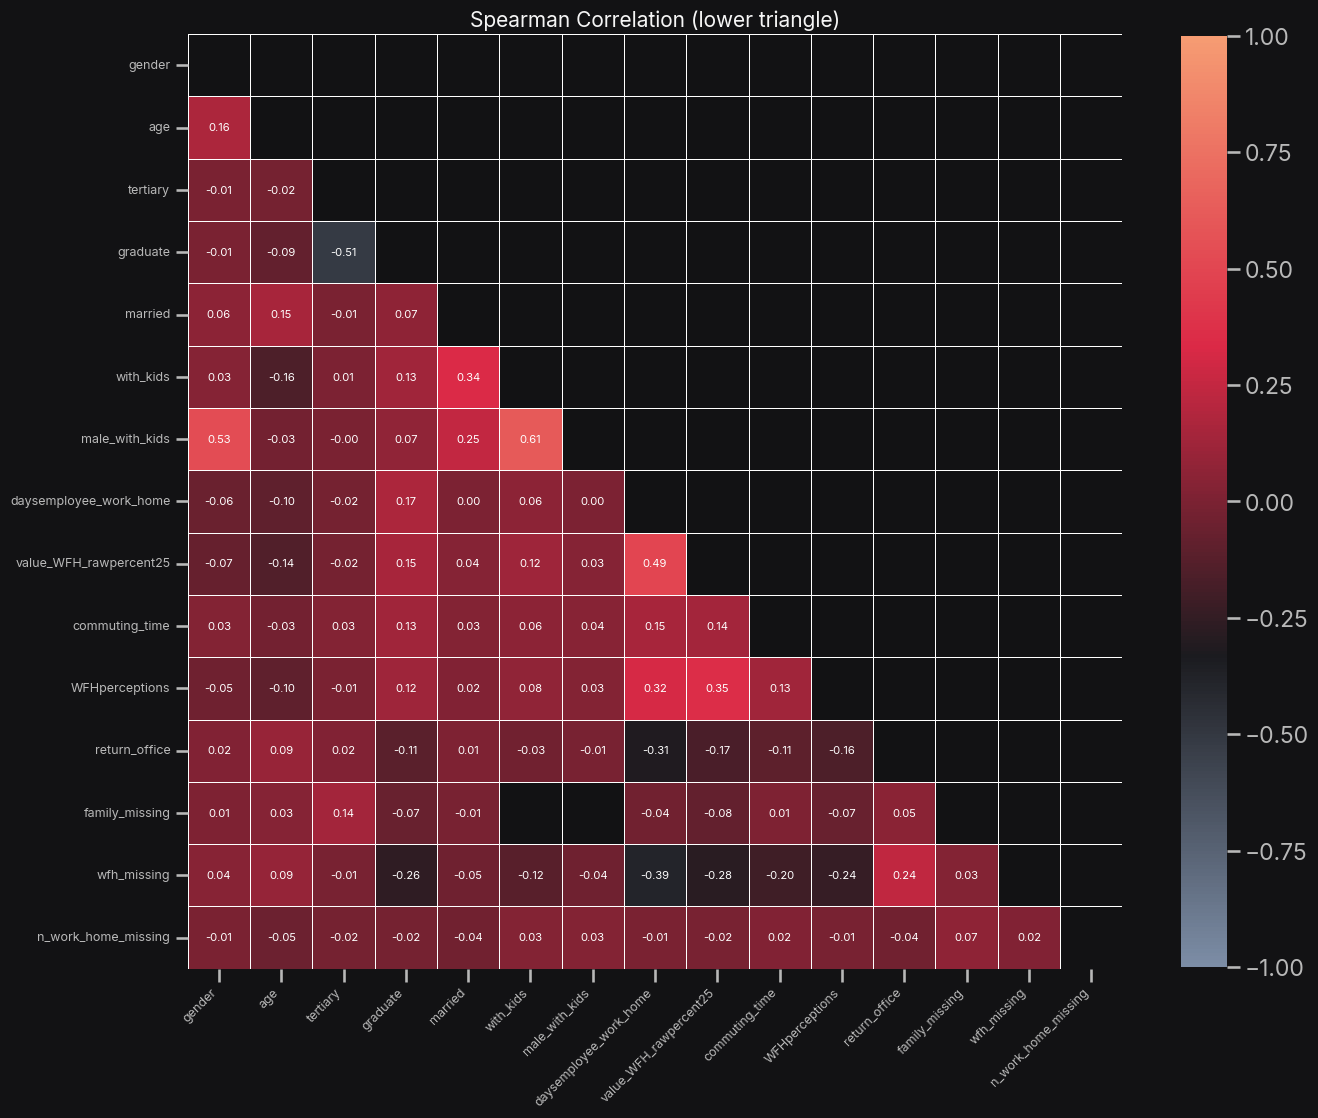

In [43]:
# Spearman to match the ordinal framing
corr = cols_corr.corr(method='spearman', numeric_only=True)

# --- View 1: matrix for spotting REDUNDANCY between features ---
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))          # lower triangle only, halves the clutter
sns.heatmap(corr, mask=mask, cmap=ROCKET_DIV, annot=True, fmt='.2f',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.9}, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.title("Spearman Correlation (lower triangle)", fontsize=15)
plt.tight_layout()
plt.savefig("fig_corr_heatmap.png", dpi=150, bbox_inches='tight')  # save for slides

# --- View 2: each feature's monotonic association with the TARGET ---
target_corr = (corr['return_office']
               .drop('return_office')
               .sort_values(key=abs, ascending=False))
print(target_corr)

#### 3.3.2 Observations
<b> Context refresher: Wave 2 global survey was conducted in 2022, mid-pandemic, when disruptions to work were inconsistent around the world and across industries. </b>

* Employees who have experienced WFH appear to have warmer views towards hybrid work arrangements, signalled primarily through `daysemployee_work_home` (ρ = -0.31). 
* An employees age, in addition to not having WFH experience, appears to also have an influence on whether one desires returning to physical office. `wfh_missing` (ρ = +0.24) comes in a close second, suggesting that NaN values surfaced in the original `WFH_expectations1` column are <i>not noise</i>. Instead, it supports the view that had one not had exposure to WFH (i.e. only answered Q5, and not 24), one would be more compliant in returning to physical office. Though `age` (ρ = +0.09) appears to be weak, it sits above the family columns (i.e. `family_missing` at ρ = +0.05, while the original three columns are below this ρ value). Keeping in mind that the `age` column was not fully explored, and has a paired `agegroups` column with binned age ranges, we could take one closer look before predictive modeling to uncover true correlationships here. 
* `value_WFH_rawpercent25` (ρ = -0.17) and `WFHperceptions` (ρ = -0.16) add credence to the aforementioned initial understanding that WFH experience plays in indelible role in one's desire to return to physical office.
* `graduate` (ρ = -0.17) might also carry a DEI/attrition slant for analysis, in that higher paper-qualified employees might resist returning to physical office more.
* `commute_time` (ρ = -0.11) has a clear rational cost-avoidance correlation with `return_office` (i.e. longer commute = less keen on returning to physical office).

<i> For further cleaning consideration [Not urgent as it won't impact modeling moving forward] </i>
* To consider removing either `tertiary` or `graduate` as these have overlapping signals
* In addition to being one of the last few columns to carry NaNs (~8%), `n_work_home` is a near duplicate of `daysemployee_work_home`. Might be justification to remove completely.  

#### 3.3.3 Plot 1: Feature Ranking

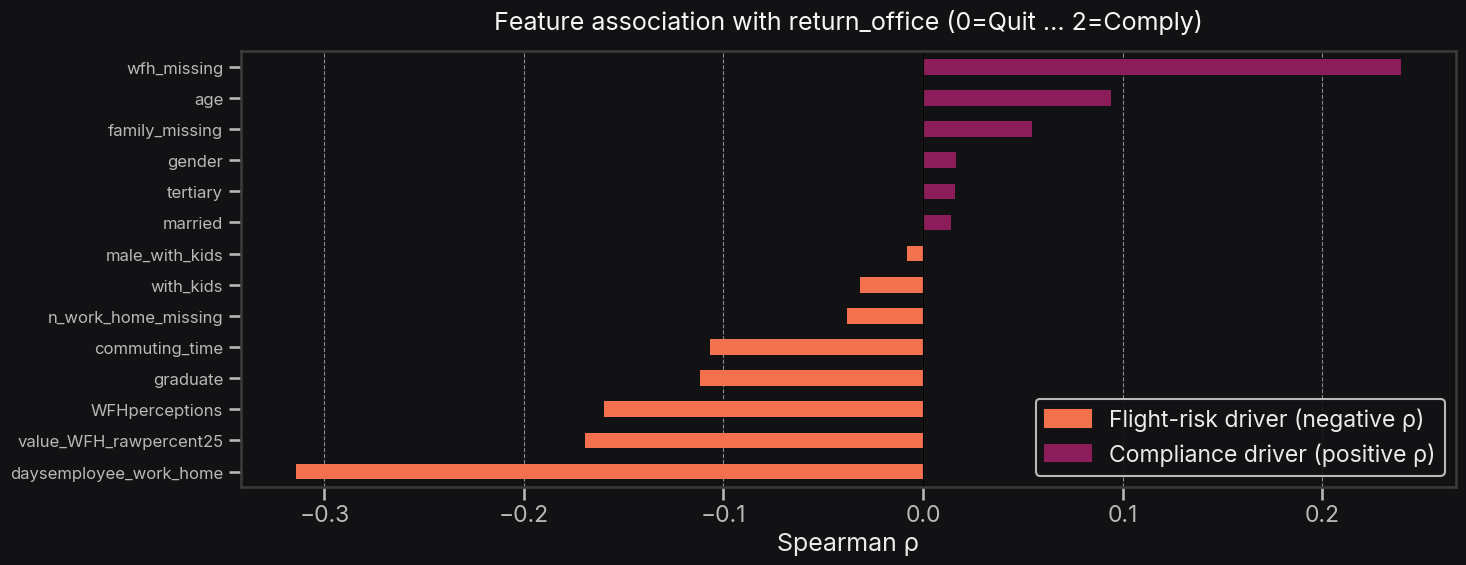

In [44]:
# Plot 1: Feature ranking by association with target (feature-selection visual)

s = target_corr.sort_values()
colors = [RISK if v < 0 else COMPLY for v in s]

fig, ax = plt.subplots(figsize=(15, 6))
s.plot(kind='barh', color=colors, ax=ax)
ax.axvline(0, color='k', lw=0.8)
ax.set_title("Feature association with return_office (0=Quit … 2=Comply)", pad=16)
ax.set_xlabel("Spearman ρ")

# Light grid on x-axis only (behind bars)
ax.set_axisbelow(True)                                        
ax.xaxis.grid(True, color=NEUTRAL, linewidth=0.8, linestyle="--")
ax.yaxis.grid(False)

# legend 
legend_patches = [
    mpatches.Patch(color=RISK, label='Flight-risk driver (negative ρ)'),
    mpatches.Patch(color=COMPLY, label='Compliance driver (positive ρ)'),
]
ax.legend(handles=legend_patches, loc='lower right', framealpha=0.9)
ax.tick_params(axis='y', labelsize=12)  

plt.tight_layout()
plt.savefig("fig_target_corr.png", dpi=150, bbox_inches='tight')
plt.show()

#### 3.3.4 Plot 2: Compliance vs WFH days

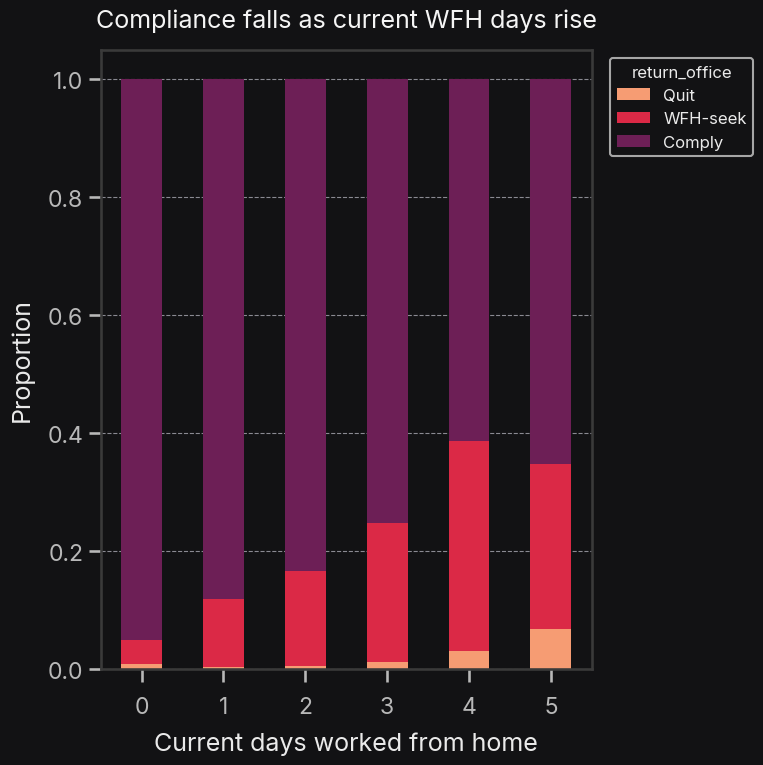

In [45]:
# Plot 2: Visualising the -0.31 correlation between 'return_office' and 'daysemployee_work_home'
prop = pd.crosstab(df_w2['daysemployee_work_home'], df_w2['return_office'], normalize='index')
prop.columns = ['Quit', 'WFH-seek', 'Comply']

ax = prop.plot(kind='bar', stacked=True, figsize=(8, 8),        
               color=(CLS["Quit"], CLS["WFH-seek"], CLS["Comply"]))

# Light grid on x-axis only (behind bars)
ax.set_axisbelow(True)                                        
ax.xaxis.grid(False)
ax.yaxis.grid(True, color=NEUTRAL, linewidth=0.8, linestyle="--")
ax.tick_params(axis='x', labelrotation=0, pad=10)

plt.ylabel("Proportion",labelpad=10)
plt.xlabel("Current days worked from home", labelpad=10)
plt.title("Compliance falls as current WFH days rise", pad=16)
plt.legend(title="return_office", bbox_to_anchor=(1.02, 1), fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.savefig("fig_wfh_days.png", dpi=150, bbox_inches='tight')

#### 3.3.5 Plot 3: Geography of resistance

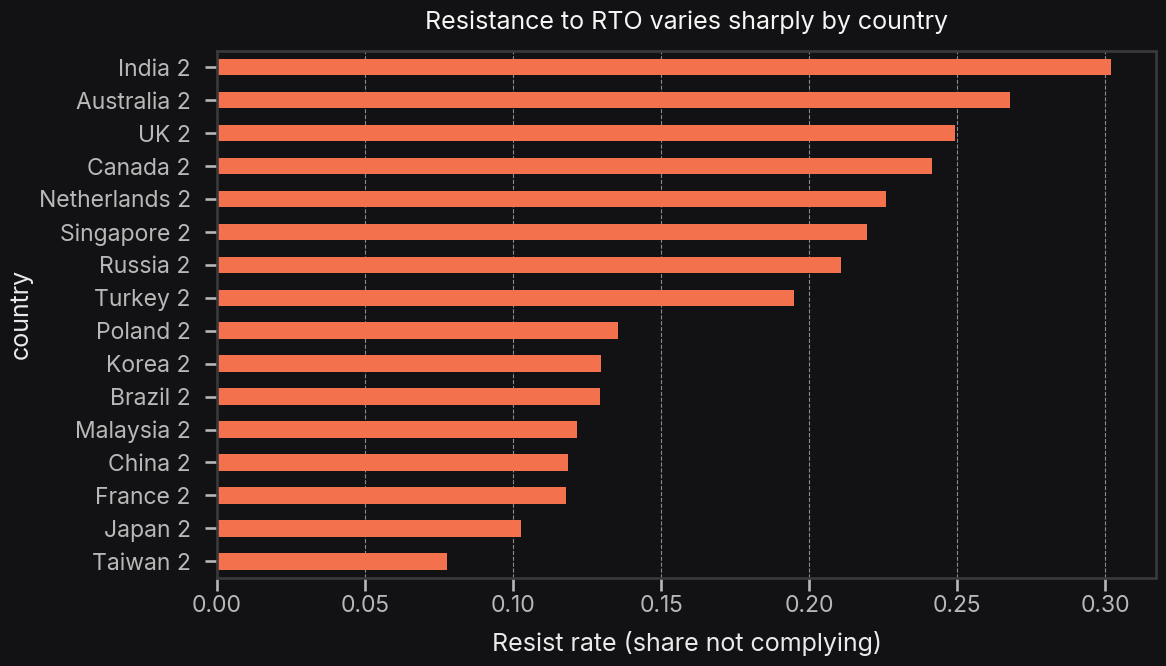

In [46]:
# Plot 3: Resistance to RTO by country (horizontal bar)
resist = df_w2.assign(resist=(df_w2['return_office'] < 2).astype(int))  # <2 means not complying
by_country = resist.groupby('country')['resist'].mean().sort_values()    # resist rate per country

fig, ax = plt.subplots(figsize=(12, 7))
pd.concat([by_country.head(8), by_country.tail(8)]).plot(
    kind='barh', color=RISK, ax=ax)

ax.set_axisbelow(True)
ax.yaxis.grid(False)
ax.xaxis.grid(True, color=NEUTRAL, linewidth=0.8, linestyle="--")  # grid on value axis for barh
ax.tick_params(axis='y', pad=10)

plt.xlabel("Resist rate (share not complying)", labelpad=10)
plt.title("Resistance to RTO varies sharply by country", pad=16)
plt.tight_layout()
plt.savefig("fig_country.png", dpi=150, bbox_inches='tight')

#### 3.3.6 Plot 4: Age compliance to RTO

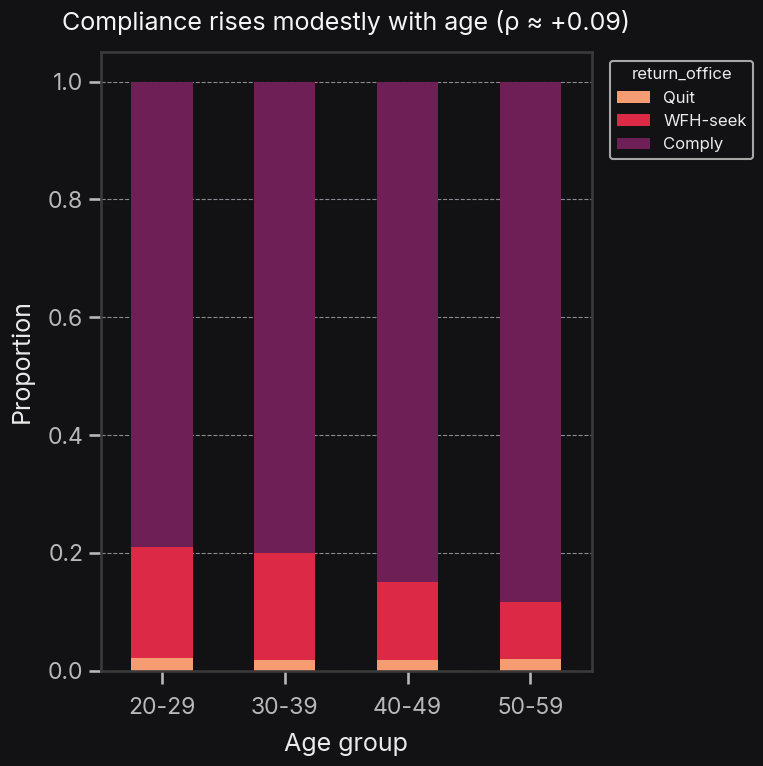

In [47]:
# Plot 4: Compliance by age band (stacked proportion bar)
age_order = ['20-29', '30-39', '40-49', '50-59']                        # enforce chronological order
prop_age = (pd.crosstab(df_w2['agegroups'], df_w2['return_office'],
                        normalize='index')                              # row % so bands are comparable
            .reindex(age_order))
prop_age.columns = ['Quit', 'WFH-seek', 'Comply']

ax = prop_age.plot(kind='bar', stacked=True, figsize=(8, 8),
                   color=(CLS["Quit"], CLS["WFH-seek"], CLS["Comply"]))             # dark→light = worst→best outcome

ax.set_axisbelow(True)
ax.xaxis.grid(False)
ax.yaxis.grid(True, color=NEUTRAL, linewidth=0.8, linestyle="--")
ax.tick_params(axis='x', labelrotation=0, pad=10)

plt.ylabel("Proportion", labelpad=10)
plt.xlabel("Age group", labelpad=10)
plt.title("Compliance rises modestly with age (ρ ≈ +0.09)", pad=16)
plt.legend(title="return_office", bbox_to_anchor=(1.02, 1), fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.savefig("fig_agegroups.png", dpi=150, bbox_inches='tight')

#### 3.3.7 Plot 5: `Pyplot` to visualise age resist-rate

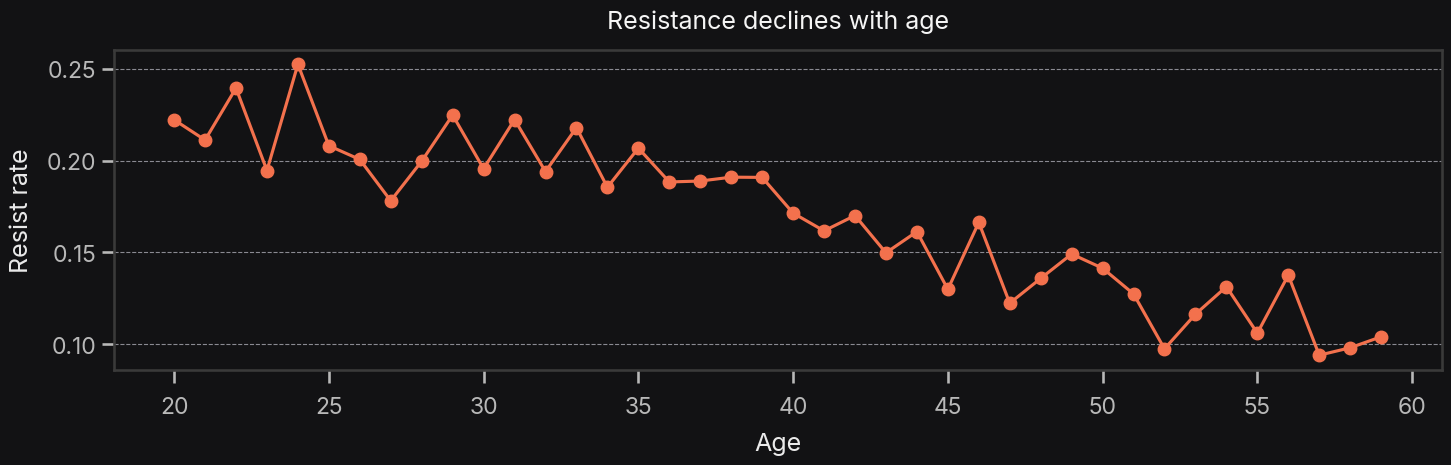

In [48]:
# Plot 5: Resist rate as a continuous function of age (line plot)
resist_by_age = (df_w2.assign(resist=(df_w2['return_office'] < 2))    # not complying
                 .groupby('age')['resist'].mean())

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(resist_by_age.index, resist_by_age.values, marker='o', color=RISK)

ax.set_axisbelow(True)
ax.xaxis.grid(False)
ax.yaxis.grid(True, color=NEUTRAL, linewidth=0.8, linestyle="--")
ax.tick_params(axis='x', pad=10)

plt.xlabel("Age", labelpad=10)
plt.ylabel("Resist rate", labelpad=10)
plt.title("Resistance declines with age", pad=16)
plt.tight_layout()
plt.savefig("fig_age_line.png", dpi=150, bbox_inches='tight')

#### 3.3.8 Plot 6: Mapping resistance drivers

C:\Users\micha\AppData\Local\Temp\ipykernel_38864\3684483435.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=tmp, x='outcome', y='commuting_time',


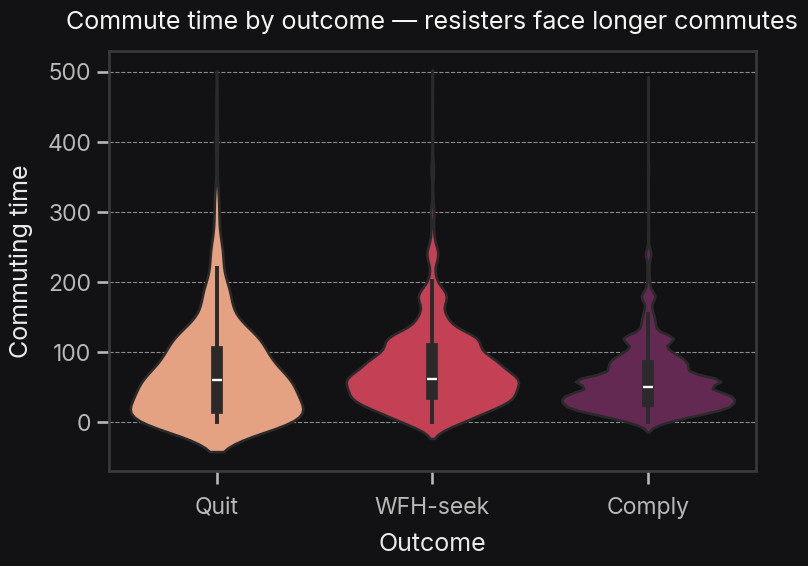

In [49]:
# Plot 6A: Commute time by outcome (violin)
tmp = df_w2.assign(outcome=df_w2['return_office'].map({0: 'Quit', 1: 'WFH-seek', 2: 'Comply'}))

fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(data=tmp, x='outcome', y='commuting_time',
               order=['Quit', 'WFH-seek', 'Comply'],
               palette=[CLS["Quit"], CLS["WFH-seek"], CLS["Comply"]], ax=ax)   # swap y='commuting_time' for 'WFHperceptions' or 'value_WFH_rawpercent25'

ax.set_axisbelow(True)
ax.xaxis.grid(False)
ax.yaxis.grid(True, color=NEUTRAL, linewidth=0.8, linestyle="--")
ax.tick_params(axis='x', labelrotation=0, pad=10)

plt.xlabel("Outcome", labelpad=10)
plt.ylabel("Commuting time", labelpad=10)
plt.title("Commute time by outcome — resisters face longer commutes", pad=16)
plt.tight_layout()
plt.savefig("fig_commute_violin.png", dpi=150, bbox_inches='tight')

C:\Users\micha\AppData\Local\Temp\ipykernel_38864\2314283853.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=fam, x='kids', y='ro_num', order=['No kids', 'Has kids'],
C:\Users\micha\AppData\Local\Temp\ipykernel_38864\2314283853.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=fam, x='marital', y='ro_num', order=['Not married', 'Married'],


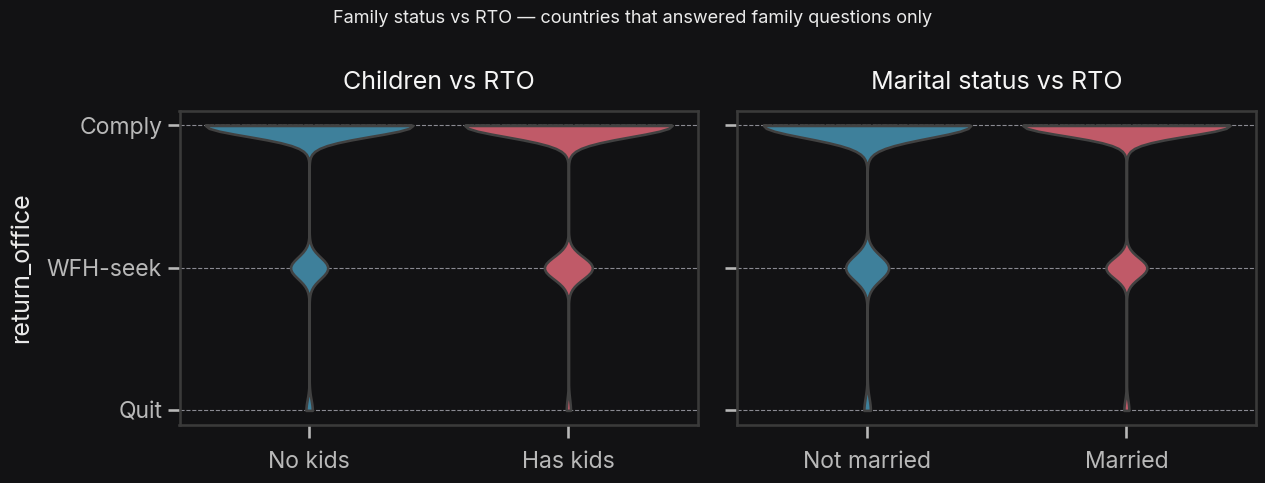

In [50]:
# Plot 6B: Family status vs RTO (paired violins, countries that answered family questions only)
family_first = df_w2[df_w2['family_missing'] == 0].copy()              # drop the 10 NaN countries via flag
fam = family_first.assign(
    ro_num=family_first['return_office'].astype(float),                # violin needs numeric y
    kids=family_first['with_kids'].map({0: 'No kids', 1: 'Has kids'}),
    marital=family_first['married'].map({0: 'Not married', 1: 'Married'})
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax in axes:
    ax.set_axisbelow(True)
    ax.xaxis.grid(False)
    ax.yaxis.grid(True, color=NEUTRAL, linewidth=0.8, linestyle="--")
    ax.tick_params(axis='x', labelrotation=0, pad=10)

sns.violinplot(data=fam, x='kids', y='ro_num', order=['No kids', 'Has kids'],
               cut=0, inner='quartile', palette=['#2e86ab', '#d1495b'], ax=axes[0])  # cut=0 keeps it in 0–2
axes[0].set_title('Children vs RTO', pad=16)
axes[0].set_xlabel('', labelpad=10)
axes[0].set_ylabel('return_office', labelpad=10)
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(['Quit', 'WFH-seek', 'Comply'])               # label once; shared axis

sns.violinplot(data=fam, x='marital', y='ro_num', order=['Not married', 'Married'],
               cut=0, inner='quartile', palette=['#2e86ab', '#d1495b'], ax=axes[1])
axes[1].set_title('Marital status vs RTO', pad=16)
axes[1].set_xlabel('', labelpad=10)

fig.suptitle('Family status vs RTO — countries that answered family questions only', fontsize=13)
plt.tight_layout()
plt.savefig("fig_family_violins.png", dpi=150, bbox_inches='tight')

#### 3.3.9 Plot 7: Visualising the education ladder

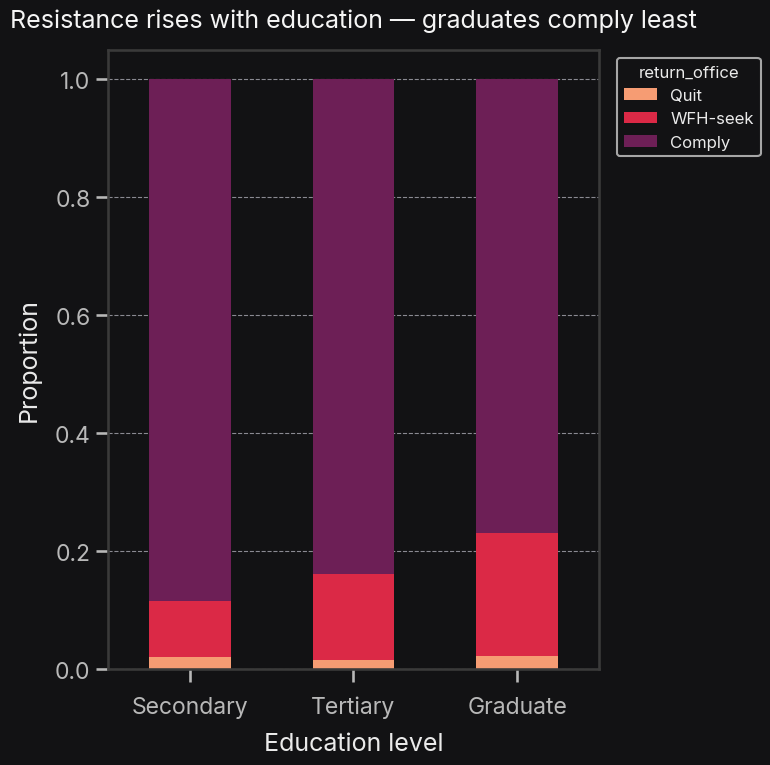

In [51]:
# Plot 7: Compliance by education level (stacked proportion bar)
edu_order = ['Secondary', 'Tertiary', 'Graduate']
prop_edu = (pd.crosstab(df_w2['education'], df_w2['return_office'], normalize='index')
            .reindex(edu_order))
prop_edu.columns = ['Quit', 'WFH-seek', 'Comply']

ax = prop_edu.plot(kind='bar', stacked=True, figsize=(8, 8),
                   color=[CLS["Quit"], CLS["WFH-seek"], CLS["Comply"]])

ax.set_axisbelow(True)
ax.xaxis.grid(False)
ax.yaxis.grid(True, color=NEUTRAL, linewidth=0.8, linestyle="--")
ax.tick_params(axis='x', labelrotation=0, pad=10)

plt.ylabel("Proportion", labelpad=10)
plt.xlabel("Education level", labelpad=10)
plt.title("Resistance rises with education — graduates comply least", pad=16)
plt.legend(title="return_office", bbox_to_anchor=(1.02, 1), fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.savefig("fig_education.png", dpi=150, bbox_inches='tight')

<a id="methodology"></a>
## 4. Methodology

A key pre-modelling discovery was a skip-logic design in the original survey that inflated the Comply class to ~83% of responses — a base-rate trap that makes naive accuracy misleading and required explicit handling before any modelling. <b>Multinomial logistic regression</b> was selected as the final model for its interpretability and native support for `predict_proba`, which enabled a per-employee flight-risk score as a practical business output.

<a id="modelling"></a>
## 5. Predictive Modelling

### 5.1 Feature selection: building X and y

In [52]:
# Drop 7 columns for model (rationale below) 
drop_for_model = [
    "idnum",                # no signal
    "wave",                 # zero variance as constant 2
    "agegroups",            # redundant with continuous 'age' column
    "education",            # redundant with 'tertiary' and 'graduate'
    "n_work_home",          # near-duplicate of 'daysemployee_work_home'; to perform country-wise median on columns with high NaN
    "n_work_home_missing",  # 'n_work_home''s NaN flag has ~0 correlation with target (-0.04)
    "WFH_expectations1",    # redudant with ~47.7% NaN; signal captured by the 'wfh_missing' flag
]

# Setup new dataframe for modeling; has 16 columns
model_df = df_w2.drop(columns=drop_for_model)                  

# Family columns: fill NaN with 0 (affects ~39% of rows); the NaN signal remains in 'family_missing'
for col in ["married", "with_kids", "male_with_kids"]:
    model_df[col] = model_df[col].fillna(0)                    

# Dropping NaN rows in 'gender' column (loss of 35 rows, < 0.15%)
model_df = model_df.dropna(subset=["gender"])                 

# One-hot encoding of categorical 'country' and 'industry_job' into binary; results in 55 columns
model_df = pd.get_dummies(model_df, 
                          columns=["country", "industry_job"],
                          drop_first=True,  # remove arbitrary category p/column to avoid perfect collinearity
                          dtype=int         # ^ changes what country coefficients mean
)

# Defining target 'y' and inputs 'X'
y = model_df["return_office"].astype(int)     # 0=Quit, 1=WFH-seek, 2=Comply
X = model_df.drop(columns=["return_office"])  # all remaining columns are predictors

# Ensures zero NaNs are fed into model
assert X.isna().sum().sum() == 0, X.columns[X.isna().any()].tolist()  

# Check 2D array shape of inputs' X, and count of target {83% Comply : 15% WFH-seek : 2% Quit}
print("X shape:", X.shape, "| classes:", y.value_counts().to_dict())

X shape: (23814, 54) | classes: {2: 19790, 1: 3572, 0: 452}


### 5.2 Stratified split and scaling to ensure train-test is leakage-safe

In [53]:
# Setup train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,     # 80/20 train-test split
    random_state=42,    # fixed seed for reproducible results
    stratify=y)         # keeps the predictor classes' 83/15/2 ratio identical in both sets
                        # avoid test set targeting 0% Quit rows by chance

# Feature scaling transformation to have mean 0 and std 1
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train) # Models learn from X_train's mean/std of each column    
                                         
X_test_s  = scaler.transform(X_test)      # Reuse X_train's mean/std on X_test

### 5.3 Setting up the models

In [54]:
# Building 4 models for comparison
models = {
    "Baseline (majority)": DummyClassifier(strategy="most_frequent"),   # Dummy: a dummy model which always predict Comply (83% raw accuracy 
                                                                               # i.e. Sum(True Predictions)/Sum(Sample count))
    "Naive Bayes":         GaussianNB(),                                # NB: Bayes' Theorem assumes every feature is independent given class, 
                                                                               # & normally distributed within each class
    "KNN (k=15)":          KNeighborsClassifier(n_neighbors=15),        # KNN: Find 15 most similar workers in scaled feature space without training phase; 
                                                                               # problem for Quit (2% raw accuracy = 15 NN will always lead to 0% Quit Recall i.e. TP/Sum(TP+FN))
    "Logistic Regression": LogisticRegression(max_iter=1000,            # multinomial LogReg: learns one coefficient per feature per class; three linear scores, P(0)+P(1)+P(2) = 1
                                                                               # increased max_iter to 1000 for solver to converge on 54 features
                                              class_weight="balanced"),        # up-weights the 2% Quit class, inflating predicted probabilities for minorities -> treat as relative scores
}

# Dictionary where every model is trained on X_train_s for comparison; to be used for evaluation loop (see next cell)
fitted = {name: m.fit(X_train_s, y_train) for name, m in models.items()} 

### 5.4 Model analysis and evaluation

In [55]:
# Model evaluation loop for class predictions on unseen X_test_s
for name, model in fitted.items():
    y_pred = model.predict(X_test_s)
    print("=-" * 28, f"\n{name}")
    print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred), 3))  # avverage recall of multiclass; immune to imbalance
    print("Macro-F1        :", round(f1_score(y_test, y_pred, average='macro'), 3)) # model perf score based on "precision + recall" 
                                                                                           # OR average F1 score of multiclass
    
    print(classification_report(y_test, y_pred,                                     # summary of key classification metrics per-class
          target_names=["Quit(0)", "WFH-seek(1)", "Comply(2)"], zero_division=0))          # precision (TP/Sum(TP+FP)), recall (TP/Sum(TP+FN))
                                                                                           # f1 (harmonic mean i.e. "precision + recall)
                                                                                           # zero_division=0 (Quit_precision=0 for baseline & KNN)

=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=- 
Baseline (majority)
Balanced accuracy: 0.333
Macro-F1        : 0.303
              precision    recall  f1-score   support

     Quit(0)       0.00      0.00      0.00        90
 WFH-seek(1)       0.00      0.00      0.00       715
   Comply(2)       0.83      1.00      0.91      3958

    accuracy                           0.83      4763
   macro avg       0.28      0.33      0.30      4763
weighted avg       0.69      0.83      0.75      4763

=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=- 
Naive Bayes
Balanced accuracy: 0.422
Macro-F1        : 0.236
              precision    recall  f1-score   support

     Quit(0)       0.02      0.81      0.05        90
 WFH-seek(1)       0.29      0.10      0.15       715
   Comply(2)       0.91      0.35      0.51      3958

    accuracy                           0.32      4763
   macro avg       0.41      0.42      0.24      4763
weighted avg       0.80      0.32      0.45    

=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=- 
KNN (k=15)
Balanced accuracy: 0.345
Macro-F1        : 0.33
              precision    recall  f1-score   support

     Quit(0)       0.00      0.00      0.00        90
 WFH-seek(1)       0.37      0.05      0.09       715
   Comply(2)       0.84      0.99      0.90      3958

    accuracy                           0.83      4763
   macro avg       0.40      0.34      0.33      4763
weighted avg       0.75      0.83      0.76      4763

=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=- 
Logistic Regression
Balanced accuracy: 0.557
Macro-F1        : 0.403
              precision    recall  f1-score   support

     Quit(0)       0.06      0.54      0.10        90
 WFH-seek(1)       0.28      0.51      0.36       715
   Comply(2)       0.94      0.62      0.74      3958

    accuracy                           0.60      4763
   macro avg       0.43      0.56      0.40      4763
weighted avg       0.82      0.60      0.68      

#### 5.4.1 Observations
* Balanced accuracy is the mean of three Recalls (i.e. Recall*(Quit + WFH + Comply) / 3)
* The Logistic Regression model performs "the best" out of the group with a balanced accuracy of <b>0.557</b>
    * Catches half of the quitters (i.e. 94% flags are false alarms)
    * Moderate on both Precision (28%) and Recall (51%) for WFH-seek
    * Excellent Precision (94%) and moderate Recall (62%) for Comply
    * Weighted average Precision score appears great (82%) but is a reporting metric influenced by the high Precision score.
* To prod the model further:
    1. to manually apply weights to <i>class_weight</i> instead of 'balanced' (17.6 value) to see if Precision and Recall scores can improve
    2. to optimise lower P(Quit) threshold as implicit threshold is "argmax wins" (i.e P(Quit) has to be highest of the three classes' Ps)

### 5.5 Tuning the Logistic Regression model
#### 5.5.1 Class-weight tuning

In [56]:
# Can we improve from class_weight="balanced" by pushing Quit weight higher than "balanced"
# for better balanced accuracy / macro-F1 while keeping remaining two classes the same?

# Define a search grid for Quit weight (minority class)
quit_weights  = [10, 17.6, 25, 35, 50, 75, 100]   # 17.6 = current "balanced" value
wfh_weight    = 2.2    # keep fixed 
comply_weight = 0.4    # keep fixed

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

weight_rows = []
for qw in quit_weights:
    cw = {0: qw, 1: wfh_weight, 2: comply_weight}
    lr_tuned = LogisticRegression(max_iter=1000, class_weight=cw)
    
    ba = cross_val_score(lr_tuned, X_train_s, y_train,                   # cross-validation on X_train_s only
                         cv=skf, scoring="balanced_accuracy").mean()
    f1 = cross_val_score(lr_tuned, X_train_s, y_train,
                         cv=skf, scoring="f1_macro").mean()
    weight_rows.append({"quit_weight": qw, "bal_acc_cv": round(ba, 3),
                                           "f1_macro_cv": round(f1, 3)})
    print(f"Quit weight {qw:5.1f} → bal_acc={ba:.3f}  macro_F1={f1:.3f}")

weight_df = pd.DataFrame(weight_rows)
best = weight_df.loc[weight_df["bal_acc_cv"].idxmax()]
print(f"\nBest Quit weight by balanced accuracy: {best['quit_weight']} "
      f"(bal_acc={best['bal_acc_cv']}, macro_F1={best['f1_macro_cv']})")

Quit weight  10.0 → bal_acc=0.541  macro_F1=0.430


Quit weight  17.6 → bal_acc=0.543  macro_F1=0.400


Quit weight  25.0 → bal_acc=0.544  macro_F1=0.377


Quit weight  35.0 → bal_acc=0.525  macro_F1=0.344


Quit weight  50.0 → bal_acc=0.495  macro_F1=0.302


Quit weight  75.0 → bal_acc=0.458  macro_F1=0.251


Quit weight 100.0 → bal_acc=0.437  macro_F1=0.217

Best Quit weight by balanced accuracy: 25.0 (bal_acc=0.544, macro_F1=0.377)


#### 5.5.2 Observations
* Weight 10 gives best macro-F1 (harmonic mean) in entire search grid (improvement from 0.403 in single split to <b>0.430</b>
* This is a reduction in Quit's weight from 'balanced' (17.6 value)
* More-or-less consistent bal_acc, peaking at 25 by only <b>0.001</b>
    * → to interpret as noise
    * → manual weighting shifts have little impact here
    * → huge distinction / decision boundary between Quit class and other two classes is preventing better accuracy performance
* Therefore <i>class_weight</i> can be modified as follows:
    * Higher Precision, Lower Recall = "Balanced" → Catch the Quitters
    * Lower Precision, Higher Recall = Apply "10" weight → Surface more employees for prioritised retention conversations

#### 5.5.3 Threshold tuning

In [57]:
#Threshold optimisation for Quit class

# Pull trained LogReg model from fitted dict, apply to X_test_s 
proba = fitted["Logistic Regression"].predict_proba(X_test_s)
# Ensure class columns are ordered: P(Quit), P(WFH), P(Comply)
quit_col = list(fitted["Logistic Regression"].classes_).index(0)

# Try different thresholds for flagging Quit risk (i.e. go lower than argmax, Quit Recall of 0.54)
for threshold in [0.05, 0.10, 0.15, 0.20, 0.25, 0.33]:
    
    # Flag as Quit if P(Quit) exceeds threshold
    quit_flags = (proba[:, quit_col] > threshold).astype(int)    # extract P(Quit) column with boolean array where True = P(Quit) exceeds threshold
    actual_quit = (y_test == 0).astype(int)                      # 1 = TP(Quit), else 0 (i.e. FP(Quit))
    
    tp = ((quit_flags == 1) & (actual_quit == 1)).sum()          # model flagged quit & TP(Quit)=1
    fp = ((quit_flags == 1) & (actual_quit == 0)).sum()          # model flagged quit & TP(Quit)=0
    fn = ((quit_flags == 0) & (actual_quit == 1)).sum()          # model flagged stayed & TP(Quit)=1

    # all three metrics avoid division by 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0           # correct positive predictions (exact)
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0           # actual positive predicitons (complete... out of 90 quitters)
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0 # harmonic mean to punish Precision-Recall imbalance
    
    print(f"Threshold {threshold:.2f} → "
          f"Quit recall={recall:.2f}  precision={precision:.2f}  "
          f"F1={f1:.2f}  flags raised={quit_flags.sum()}")       # quit_flags.sum() = total no. of workers flagged at threshold = positive predictions (TP+FP)

Threshold 0.05 → Quit recall=0.94  precision=0.02  F1=0.04  flags raised=4315
Threshold 0.10 → Quit recall=0.92  precision=0.02  F1=0.05  flags raised=3536
Threshold 0.15 → Quit recall=0.90  precision=0.03  F1=0.06  flags raised=2832
Threshold 0.20 → Quit recall=0.79  precision=0.03  F1=0.06  flags raised=2266
Threshold 0.25 → Quit recall=0.68  precision=0.03  F1=0.07  flags raised=1782
Threshold 0.33 → Quit recall=0.62  precision=0.04  F1=0.08  flags raised=1255


#### 5.5.4 Observations
* Model's P(Quit) Precision scores are compressed into a narrow range (0.02 – 0.04) in that most workers get assigned a small but non-trivial Quit probability
* As the threshold is lowered from 0.33 to 0.05, the model scoops up larger numbers of borderline workers before getting to true quitters (~362 in X_train set)
* Can consider using P(Quit) score as <u>a ranking tool for retention conversations</u>, not a binary flag to see who will leeave or stay 

### 5.6 Diagnostic evaluation: confusion matrices and ROC
#### 5.6.1 Confusion matrices 

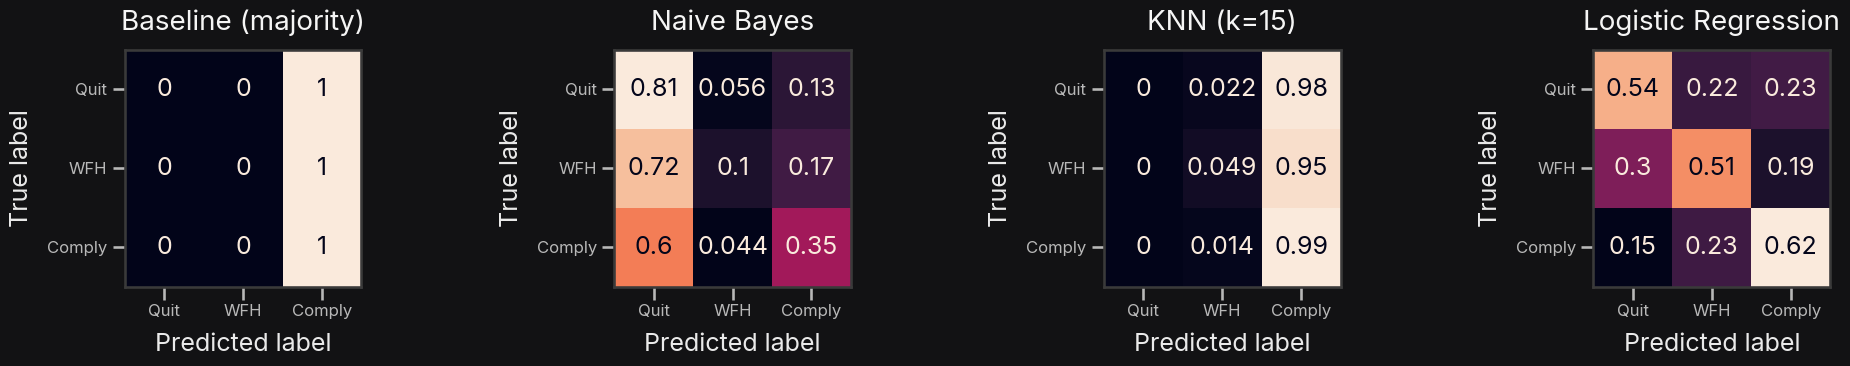

In [58]:
# Confusion matrices side by side (row-normalised = per-class recall on the diagonal)
fig, axes = plt.subplots(1, len(fitted), figsize=(5 * len(fitted), 4))
for ax, (name, model) in zip(axes, fitted.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, model.predict(X_test_s), display_labels=["Quit", "WFH", "Comply"],
        normalize='true', cmap='rocket', ax=ax, colorbar=False)
    ax.set_title(name, fontsize=20, pad=14)                   
    ax.set_xlabel(ax.get_xlabel(), labelpad=10)               
    ax.set_ylabel(ax.get_ylabel(), labelpad=10)      
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
    
plt.tight_layout(); plt.savefig("fig_confusion.png", dpi=150, bbox_inches='tight')

# How to read a 3x3 grid layout
#===========  P R E D I C T E D ======
#= T =======Quit======WFH======Comply=
#= R =======TPa=======FPb======FPc====
#= U =======FPa=======TPb======FPc====
#= E =======FPa=======FPb======TPc====

#### 5.6.2 Calculating Macro-Average ROC AUC (AUROC)

In [59]:
# As ROC is binary, need to convert multiclass label into 3 binary columns
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])        # multiclass ROC = 3 one-vs-rest (OvR)        
for name, model in fitted.items():
    proba = model.predict_proba(X_test_s)                      # per-class probabilities (n_rows x 3)
    mac_auc = roc_auc_score(y_test_bin, proba, average="macro", multi_class="ovr") # compute AUC for each of the 3 OvR problems, then averages equally; measures class-ranking quality
    print(f"{name:22s} macro OvR AUC = {mac_auc:.3f}")

Baseline (majority)    macro OvR AUC = 0.500
Naive Bayes            macro OvR AUC = 0.626
KNN (k=15)             macro OvR AUC = 0.647
Logistic Regression    macro OvR AUC = 0.746


#### 5.6.3 Comparative Visualisation of Macro-Average AUROC Plots

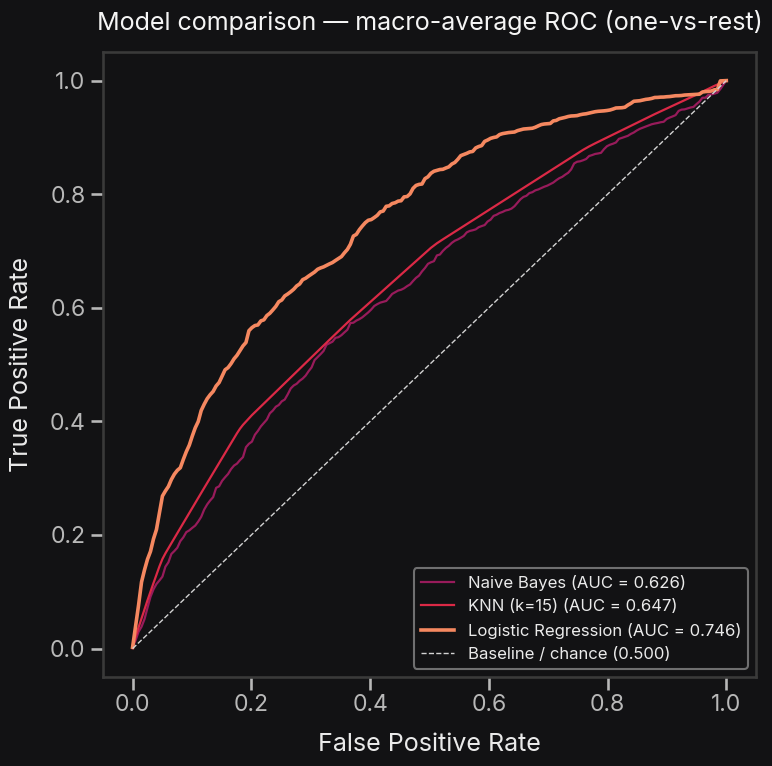

In [60]:
# Plotting macro OvR AUROCs on one-axis for model comparison

model_colors = MODEL_COLORS

mean_fpr = np.linspace(0, 1, 200)                        # common grid to average class curves onto

plt.figure(figsize=(8, 8))
for name, model in fitted.items():
    if name == "Baseline (majority)":                    # constant proba -> sits on the diagonal, skip
        continue
    proba = model.predict_proba(X_test_s)
    tprs = []
    for cls in [0, 1, 2]:                                # interpolate each class's ROC, then average = macro
        col = list(model.classes_).index(cls)
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls], proba[:, col])
        tprs.append(np.interp(mean_fpr, fpr, tpr))
    macro_auc = roc_auc_score(y_test_bin, proba, average="macro", multi_class="ovr")  # matches table
    lw = 2.6 if name == "Logistic Regression" else 1.6   # thicken LogRes
    plt.plot(mean_fpr, np.mean(tprs, axis=0), color=model_colors[name], lw=lw,
             label=f"{name} (AUC = {macro_auc:.3f})")
plt.plot([0, 1], [0, 1], '--', color='lightgrey', lw=1, label="Baseline / chance (0.500)")
plt.xlabel("False Positive Rate", labelpad=12); plt.ylabel("True Positive Rate", labelpad=12)
plt.title("Model comparison — macro-average ROC (one-vs-rest)", pad=16)
plt.legend(loc="lower right", fontsize=12, framealpha=0.5)
plt.tight_layout()
plt.savefig("fig_roc_compare.png", dpi=150, bbox_inches="tight")

#### 5.6.4 ROC curves for Logistic Regression, one-vs-rest

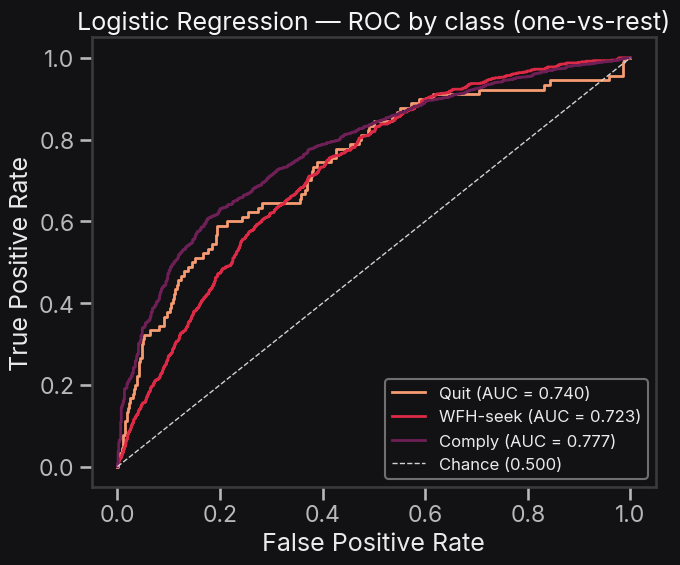

In [61]:
# Just for LogReg
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])   # 3 OvR columns
lr = fitted["Logistic Regression"]
proba = lr.predict_proba(X_test_s)

labels = {0: "Quit", 1: "WFH-seek", 2: "Comply"}
colors = {0: CLS["Quit"], 1: CLS["WFH-seek"], 2: CLS["Comply"]}      # match outcome palette (worst → best)

plt.figure(figsize=(7, 6))
for cls in [0, 1, 2]:
    col = list(lr.classes_).index(cls)                   # locate this class's proba column (don't assume order)
    fpr, tpr, _ = roc_curve(y_test_bin[:, cls], proba[:, col])
    plt.plot(fpr, tpr, color=colors[cls], lw=2,
             label=f"{labels[cls]} (AUC = {auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], '--', color='lightgrey', lw=1, label="Chance (0.500)")   # diagonal = 50-50
plt.xlabel("False Positive Rate")                        # share of non-class wrongly flagged
plt.ylabel("True Positive Rate")                         # share of class correctly caught (= Recall)
plt.title("Logistic Regression — ROC by class (one-vs-rest)")
plt.legend(loc="lower right", fontsize=12, framealpha=0.5)
plt.tight_layout()
plt.savefig("fig_roc_lr.png", dpi=150, bbox_inches="tight")  

### 5.7 Interpreting the model: Drivers of Flight Risk
Examining the LogReg model's coefficients

In [62]:
# Examining LogReg model's coefficients, which sit on standardised features, as a measure of Employee's Behaviour
# To compare feature magnitudes
lr = fitted["Logistic Regression"]                    
comply_idx = list(lr.classes_).index(2)               # locate Comply(2) row of coef_ 

# One coef p/feature for Comply class, where '+' pushes twds Comply, and '-' pushes away (i.e. quit a.k.a. flight-risk)
coef = pd.Series(lr.coef_[comply_idx],                # each = log-odds shift toward Comply per +1 std of that feature
                 index=X_train.columns,               # column order is preserved through StandardScaler
                 name="coef_toward_comply")

# Tag each feature (Country, Industry columns) so Behavioural story stays separate from the geography/industry dummies
def group(f):
    if f.startswith("country_"):      return "Country"
    if f.startswith("industry_job_"): return "Industry"
    return "Behavioural / demographic"

# Ranking key: strength regardless of sign
drivers = (coef.to_frame()
             .assign(group=[group(f) for f in coef.index],     # bucket each feature
                     abs_effect=coef.abs(),                    # strength, for ranking
                     flight_risk_push=-coef)                   # mirrored column: positive = pushes toward flight risk
             .sort_values("coef_toward_comply"))               # most negative first = strongest flight-risk drivers

# Behaviourial table: behavioural + demographic only 
behavioural = drivers[drivers["group"] == "Behavioural / demographic"]
print("TOP FLIGHT-RISK DRIVERS (push away from Comply):")
print(behavioural.head(8)[["coef_toward_comply", "flight_risk_push"]].round(3), "\n")
print("TOP COMPLIANCE DRIVERS (push toward Comply):")
print(behavioural.tail(6)[["coef_toward_comply", "flight_risk_push"]].round(3), "\n")

# Behaviourial table: surface 5 strongest country effects
country = drivers[drivers["group"] == "Country"]
print("Strongest country effects (reference):")
print(country.sort_values("abs_effect", ascending=False).head(5)[["coef_toward_comply"]].round(3))

TOP FLIGHT-RISK DRIVERS (push away from Comply):
                        coef_toward_comply  flight_risk_push
daysemployee_work_home              -0.543             0.543
commuting_time                      -0.113             0.113
gender                              -0.032             0.032
graduate                            -0.006             0.006
WFHperceptions                       0.012            -0.012
male_with_kids                       0.013            -0.013
married                              0.013            -0.013
value_WFH_rawpercent25               0.021            -0.021 

TOP COMPLIANCE DRIVERS (push toward Comply):
                        coef_toward_comply  flight_risk_push
value_WFH_rawpercent25               0.021            -0.021
tertiary                             0.037            -0.037
with_kids                            0.091            -0.091
age                                  0.153            -0.153
family_missing                       0.177        

#### 5.7.1 Observations
* Drivers of flight-risk show similarity to correlation heatmap
      
| Feature | LR Model coef | Correlation ρ |
|--|--|--|
| daysemployee_work_home | 0.543 | 0.31 |
| commuting_time | -0.113 | -0.11 |
| wfh_missing | 0.247 | 0.24 |
| age | 0.153 | 0.09 |
| graduate| 0.006 | -0.11 |

* LR measures each feature's effect holding the others constant
* Raw correlation ≠ controlled effect
* For 'graduate', the WFH-seeking behaviour is explained by their WFH experience and commuting time

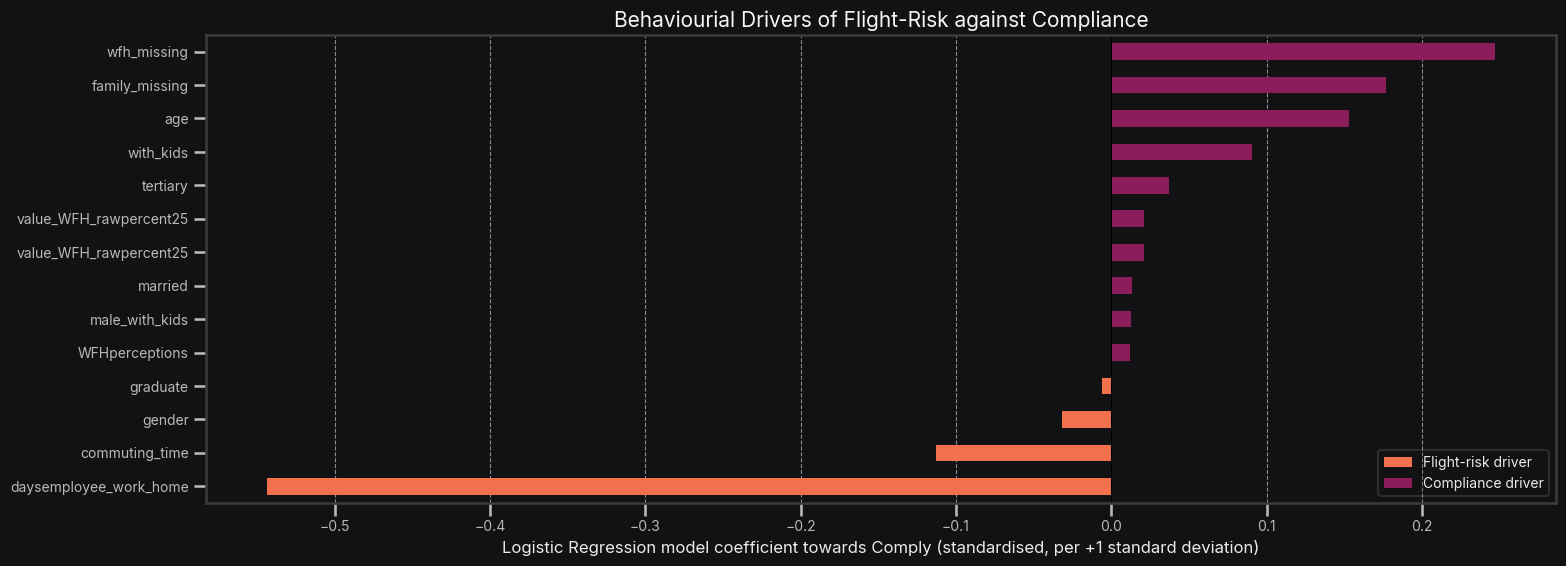

In [63]:
# Accompanying diverging bar chart
top = pd.concat([behavioural.head(8), behavioural.tail(6)]).sort_values("coef_toward_comply")
colors = [RISK if v < 0 else COMPLY for v in top["coef_toward_comply"]]

fig, ax = plt.subplots(figsize=(16, 6))
top["coef_toward_comply"].plot(kind='barh', color=colors, ax=ax)

# Zero line
ax.axvline(0, color='k', lw=0.8)

# Light grid on x-axis only (behind bars)
ax.set_axisbelow(True)                                        
ax.xaxis.grid(True, color=NEUTRAL, linewidth=0.8, linestyle="--")
ax.yaxis.grid(False)

ax.set_xlabel("Logistic Regression model coefficient towards Comply (standardised, per +1 standard deviation)", fontsize=12)
ax.tick_params(axis='both', labelsize=10)
ax.set_title("Behaviourial Drivers of Flight-Risk against Compliance", fontsize=15)

# Legend 
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=RISK, label='Flight-risk driver'),
    Patch(facecolor=COMPLY, label='Compliance driver'),
]
ax.legend(handles=legend_elements, loc='lower right', framealpha=0.15, fontsize=10)

plt.tight_layout()
plt.savefig("fig_lr_drivers.png", dpi=150, bbox_inches='tight')

### 5.8 Prediction in action: Scoring Employee Behaviourial Profiles for Flight-risk

In [64]:
# Employee Profile Archetype Scoring
import pandas as pd
from IPython.display import display, HTML

lr          = fitted["Logistic Regression"]
class_names = {0: "Quit", 1: "WFH-seek", 2: "Comply"}
cls_col     = {c: list(lr.classes_).index(c) for c in [0, 1, 2]}
comply_col  = cls_col[2]

baseline = X_train.median()

# Flight-risk tiers fitted against the test population
test_scores  = 1 - lr.predict_proba(scaler.transform(X_test))[:, comply_col]
lo, hi       = np.quantile(test_scores, [1/3, 2/3])

def tier(s):
    return "Lower" if s < lo else ("Moderate" if s < hi else "Higher")

def score(**overrides):
    row = baseline.copy()
    for k, v in overrides.items():
        if k not in row.index:
            raise KeyError(f"{k} not a feature column")
        row[k] = v
    row_s = scaler.transform(row.to_frame().T)
    pred  = lr.predict(row_s)[0]
    proba = lr.predict_proba(row_s)[0]
    return class_names[pred], proba


# Profile dicts
lever_profiles = {
    "<b>WFH experience (2 days)</b> · grad · age 38 · 60-min commute":
        dict(age=38, graduate=1, tertiary=0,
             daysemployee_work_home=2, commuting_time=60, wfh_missing=0),
    "<b>No WFH experience</b> · grad · age 38 · 60-min commute":
        dict(age=38, graduate=1, tertiary=0,
             daysemployee_work_home=0, commuting_time=60, wfh_missing=1),

    "No WFH · grad · age 38 · <b>short commute (15 min)</b>":
        dict(age=38, graduate=1, tertiary=0,
             daysemployee_work_home=0, commuting_time=15, wfh_missing=1),
    "No WFH · grad · age 38 · <b>long commute (90 min)</b>":
        dict(age=38, graduate=1, tertiary=0,
             daysemployee_work_home=0, commuting_time=90, wfh_missing=1),

    "No WFH · grad · <b>young (age 28)</b> · 60-min commute":
        dict(age=28, graduate=1, tertiary=0,
             daysemployee_work_home=0, commuting_time=60, wfh_missing=1),
    "No WFH · grad · <b>older (age 55)</b> · 60-min commute":
        dict(age=55, graduate=1, tertiary=0,
             daysemployee_work_home=0, commuting_time=60, wfh_missing=1),
}

grid_profiles = {
    "WFH experience · <b>short commute (15 min)</b>":
        dict(age=38, graduate=1, tertiary=0,
             daysemployee_work_home=2, commuting_time=15, wfh_missing=0),
    "WFH experience · <b>medium commute (45 min)</b>":
        dict(age=38, graduate=1, tertiary=0,
             daysemployee_work_home=2, commuting_time=45, wfh_missing=0),
    "WFH experience · <b>long commute (90 min)</b>":
        dict(age=38, graduate=1, tertiary=0,
             daysemployee_work_home=2, commuting_time=90, wfh_missing=0),

    "No WFH experience · <b>short commute (15 min)</b>":
        dict(age=38, graduate=1, tertiary=0,
             daysemployee_work_home=0, commuting_time=15, wfh_missing=1),
    "No WFH experience · <b>medium commute (45 min)</b>":
        dict(age=38, graduate=1, tertiary=0,
             daysemployee_work_home=0, commuting_time=45, wfh_missing=1),
    "No WFH experience · <b>long commute (90 min)</b>":
        dict(age=38, graduate=1, tertiary=0,
             daysemployee_work_home=0, commuting_time=90, wfh_missing=1),
}


# Results table
def build_results_df(profiles):
    rows = []
    for label, spec in profiles.items():
        pred_label, proba = score(**spec)
        s = 1 - proba[comply_col]          # flight-risk score
        rows.append({
            "Profile":              label,
            "Predicted":            pred_label,
            "P(Quit)":              round(proba[cls_col[0]], 3),
            "P(WFH-seek)":          round(proba[cls_col[1]], 3),
            "P(Comply)":            round(proba[cls_col[2]], 3),
            "Flight-risk score":    round(s, 2),
            "Risk tier":            tier(s),
        })
    return pd.DataFrame(rows).set_index("Profile")


# Styling
def style_results(df, title, separator_after_rows):
    class_colours = {
        "Comply":   "#d4edda",
        "WFH-seek": "#fff3cd",
        "Quit":     "#f8d7da",
    }
    tier_colours = {
        "Higher":   "#f8d7da",
        "Moderate": "#fff3cd",
        "Lower":    "#d4edda",
    }

    def highlight_predicted(row):
        colour = class_colours.get(row["Predicted"], "")
        styles = [""] * len(row)
        styles[row.index.get_loc("Predicted")] = (
            f"background-color: {colour}; font-weight: bold"
        )
        return styles

    def highlight_max_proba(row):
        proba_cols = ["P(Quit)", "P(WFH-seek)", "P(Comply)"]
        styles     = [""] * len(row)
        max_col    = row[proba_cols].astype(float).idxmax()
        styles[row.index.get_loc(max_col)] = (
            "background-color: #e8f4f8; font-weight: bold"
        )
        return styles

    def highlight_tier(row):
        colour = tier_colours.get(row["Risk tier"], "")
        styles = [""] * len(row)
        styles[row.index.get_loc("Risk tier")] = (
            f"background-color: {colour}; font-weight: bold"
        )
        return styles

    separator_styles = [
        {
            "selector": f"tr:nth-child({i + 2})",
            "props":    [("border-bottom", "2px solid #888888")]
        }
        for i in separator_after_rows
    ]

    base_styles = [
        {"selector": "caption",
         "props": [("font-size", "13px"), ("font-weight", "bold"),
                   ("text-align", "left"), ("padding-bottom", "6px")]},
        {"selector": "th",
         "props": [("background-color", "#f0f0f0"), ("font-weight", "bold"),
                   ("text-align", "center")]},
        {"selector": "td",
         "props": [("text-align", "center")]},
        {"selector": "th.row_heading",
         "props": [("text-align", "left"), ("min-width", "340px")]},
        {"selector": "tbody tr:last-child td",
         "props": [("border-bottom", "none")]},
        {"selector": "tbody tr:last-child th",
         "props": [("border-bottom", "none")]},
    ]

    styled = (
        df.style
          .apply(highlight_predicted, axis=1)
          .apply(highlight_max_proba,  axis=1)
          .apply(highlight_tier,       axis=1)
          .set_caption(title)
          .set_table_styles(base_styles + separator_styles)
    )
    return styled.to_html(escape=False)


# Output 
display(HTML(style_results(
    build_results_df(lever_profiles),
    f"Table A: Lever isolation — one feature moved per pair (age=38, graduate=1 constant) "
    f"| tercile cutoffs: lo={lo:.2f} / hi={hi:.2f}",
    separator_after_rows=[0, 2]      # after rows 2 and 4 (1-indexed data rows)
)))

print()

display(HTML(style_results(
    build_results_df(grid_profiles),
    "Table B: Risk-tier grid — WFH experience × commute length (age=38, graduate=1 constant)",
    separator_after_rows=[1]         # between WFH and No-WFH triplets
)))

print("\nNote: Flight-risk scores are relative ranks (1 − P(Comply)) under "
      "class_weight='balanced' — not literal quit/resist rates.")

,Predicted,P(Quit),P(WFH-seek),P(Comply),Flight-risk score,Risk tier
Profile,,,,,,
WFH experience (2 days) · grad · age 38 · 60-min commute,Quit,0.615000,0.260000,0.125000,0.880000,Higher
No WFH experience · grad · age 38 · 60-min commute,Comply,0.384000,0.192000,0.425000,0.580000,Moderate
No WFH · grad · age 38 · short commute (15 min),Comply,0.356000,0.181000,0.462000,0.540000,Moderate
No WFH · grad · age 38 · long commute (90 min),Quit,0.402000,0.198000,0.400000,0.600000,Moderate
No WFH · grad · young (age 28) · 60-min commute,Quit,0.396000,0.227000,0.377000,0.620000,Moderate
No WFH · grad · older (age 55) · 60-min commute,Comply,0.354000,0.139000,0.507000,0.490000,Moderate


,Predicted,P(Quit),P(WFH-seek),P(Comply),Flight-risk score,Risk tier
Profile,,,,,,
WFH experience · short commute (15 min),Quit,0.599000,0.259000,0.142000,0.860000,Higher
WFH experience · medium commute (45 min),Quit,0.610000,0.260000,0.130000,0.870000,Higher
WFH experience · long commute (90 min),Quit,0.625000,0.261000,0.114000,0.890000,Higher
No WFH experience · short commute (15 min),Comply,0.356000,0.181000,0.462000,0.540000,Moderate
No WFH experience · medium commute (45 min),Comply,0.375000,0.188000,0.437000,0.560000,Moderate
No WFH experience · long commute (90 min),Quit,0.402000,0.198000,0.400000,0.600000,Moderate



Note: Flight-risk scores are relative ranks (1 − P(Comply)) under class_weight='balanced' — not literal quit/resist rates.


### 5.9 Robustness checks: cross-validation, family drop test, ordinal model

#### 5.9.1 Cross-Validation check

In [65]:
# Stratified 5-fold cross-validation (leakage-safe via Pipeline)
# Pipeline = scaler + model together. On each fold, scaler is re-fit on that fold's training part only -> no fold-level leakage.
cv_pipes = {
    name: Pipeline([("scale", StandardScaler()), ("model", mdl)])
    for name, mdl in {
        "Baseline (majority)": DummyClassifier(strategy="most_frequent"),
        "Naive Bayes":         GaussianNB(),
        "KNN (k=15)":          KNeighborsClassifier(n_neighbors=15),
        "Logistic Regression": LogisticRegression(max_iter=1000,
                                                  class_weight="balanced"),
    }.items()
}

# Keep 83/15/2 class ratio within each fold for consistency
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
for name, pipe in cv_pipes.items():
    res = cross_validate(pipe, X, y, cv=skf,               # full X, y — CV does its own splitting;
                         scoring=["balanced_accuracy",     # 80/20 split stays untouched
                                  "f1_macro"], n_jobs=-1)
    cv_rows.append({
        "model":         name,
        "bal_acc_mean":  res["test_balanced_accuracy"].mean(),
        "bal_acc_std":   res["test_balanced_accuracy"].std(),  # spread across folds = stability
        "f1_macro_mean": res["test_f1_macro"].mean(),
        "f1_macro_std":  res["test_f1_macro"].std(),
    })

cv_results = pd.DataFrame(cv_rows).set_index("model").round(3)

# Re-collect single-split scores from fitted models on X_test_s (no re-predict needed)
single_rows = []
for name in ["Baseline (majority)", "Naive Bayes", "KNN (k=15)", "Logistic Regression"]:
    y_pred = fitted[name].predict(X_test_s)
    single_rows.append({
        "model":          name,
        "split_bal_acc":  round(balanced_accuracy_score(y_test, y_pred), 3),
        "split_f1_macro": round(f1_score(y_test, y_pred, average='macro'), 3),
    })

single_df = pd.DataFrame(single_rows).set_index("model")

# Format CV columns as mean ± std 
cv_fmt = cv_results.copy()
cv_fmt["CV Bal-Acc (mean ± std)"] = (
    cv_fmt["bal_acc_mean"].map("{:.3f}".format) + " ± " +
    cv_fmt["bal_acc_std"].map("{:.3f}".format)
)
cv_fmt["CV Macro-F1 (mean ± std)"] = (
    cv_fmt["f1_macro_mean"].map("{:.3f}".format) + " ± " +
    cv_fmt["f1_macro_std"].map("{:.3f}".format)
)

# Join hold-out + CV scores; highlight winner by balanced accuracy
compare = single_df.join(cv_fmt[["CV Bal-Acc (mean ± std)", "CV Macro-F1 (mean ± std)"]])
compare.columns = ["Hold-out Bal-Acc", "Hold-out Macro-F1",
                   "CV Bal-Acc (mean ± std)", "CV Macro-F1 (mean ± std)"]
compare.index.name = "Model"

winner = compare["Hold-out Bal-Acc"].idxmax()

def highlight_winner(row):
    return ["font-weight: bold; background-color: #d4edda"
            if row.name == winner else "" for _ in row]

display(
    compare.style
    .apply(highlight_winner, axis=1)
    .set_caption("Table 1: Model comparison: hold-out split vs. 5-fold stratified CV")
    .set_properties(**{"text-align": "center"})
)

,Hold-out Bal-Acc,Hold-out Macro-F1,CV Bal-Acc (mean ± std),CV Macro-F1 (mean ± std)
Model,,,,
Baseline (majority),0.333000,0.303000,0.333 ± 0.000,0.303 ± 0.000
Naive Bayes,0.422000,0.236000,0.486 ± 0.024,0.374 ± 0.009
KNN (k=15),0.345000,0.330000,0.349 ± 0.002,0.337 ± 0.003
Logistic Regression,0.557000,0.403000,0.554 ± 0.012,0.408 ± 0.003


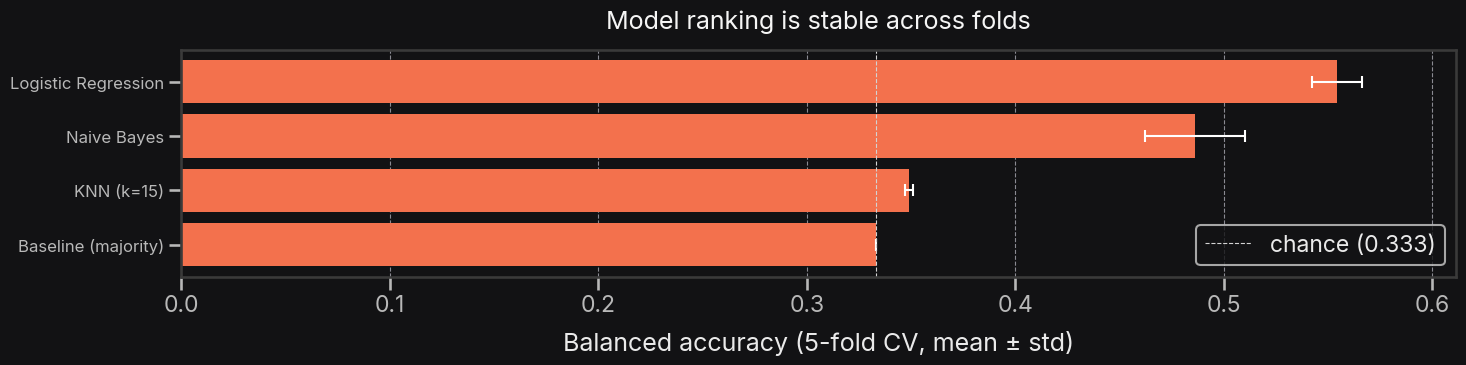

In [66]:
# Plotting mean ± std balanced accuracy across the 5 folds
fig, ax = plt.subplots(figsize=(15, 4))
order = cv_results.sort_values("bal_acc_mean").index
ax.barh(order, cv_results.loc[order, "bal_acc_mean"],
        xerr=cv_results.loc[order, "bal_acc_std"],
        error_kw=dict(capsize=4, capthick=1.5, elinewidth=1.5, ecolor='white'),  
        color=colors)
ax.axvline(1/3, color='lightgrey', ls='--', lw=0.8, label="chance (0.333)")
ax.set_xlabel("Balanced accuracy (5-fold CV, mean ± std)", labelpad=10)   
ax.set_title("Model ranking is stable across folds", pad=16)               
ax.tick_params(axis='y', labelsize=12)                                      
x_max = max(cv_results["bal_acc_mean"] + cv_results["bal_acc_std"])
ax.set_xlim(0, x_max * 1.08)                                               

# Light grid on x-axis only (behind bars)
ax.set_axisbelow(True)                                        
ax.xaxis.grid(True, color=NEUTRAL, linewidth=0.8, linestyle="--")
ax.yaxis.grid(False)

ax.legend(); plt.tight_layout()
plt.savefig("fig_cv.png", dpi=150, bbox_inches="tight")

#### 5.9.2 Observations
* Logistic Regression's CV mean minus one standard deviation is stably ranked in that it is still ahead of the next best model's mean plus one standard deviation.
* The Hold-out scores are close to the CV scores, suggesting a <i>as-good-as-it-gets</i> measure of predicting on whole dataset.

#### 5.9.3 Family Drop-test

In [67]:
# Drop-test: family columns (married, with_kids, male_with_kids)
# Does filling structural NaN in family cols with 0 harm the logistic reression model?

fam_cols = ["married", "with_kids", "male_with_kids"]

# Fit a parallel LR *without* family cols, using its own scaler (3 fewer columns)
X_train_nofam = X_train.drop(columns=fam_cols)
X_test_nofam  = X_test.drop(columns=fam_cols)

scaler_nofam  = StandardScaler()
Xtr_nf        = scaler_nofam.fit_transform(X_train_nofam)   # fit on train only — no leakage
Xte_nf        = scaler_nofam.transform(X_test_nofam)        # apply same transform to test

lr_nofam = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xtr_nf, y_train)

# Metric comparison table 
drop_rows = []
for label, mdl, Xte in [
    ("WITH family cols",    fitted["Logistic Regression"], X_test_s),
    ("WITHOUT family cols", lr_nofam,                      Xte_nf),
]:
    yp = mdl.predict(Xte)
    drop_rows.append({
        "Model variant":     label,
        "Hold-out Bal-Acc":  round(balanced_accuracy_score(y_test, yp), 3),
        "Hold-out Macro-F1": round(f1_score(y_test, yp, average="macro"), 3),
    })

drop_df = pd.DataFrame(drop_rows).set_index("Model variant")

# Winner = whichever variant has higher balanced accuracy
drop_winner = drop_df["Hold-out Bal-Acc"].idxmax()

def highlight_drop_winner(row):
    return ["font-weight: bold; background-color: #d4edda"
            if row.name == drop_winner else "" for _ in row]

display(
    drop_df.style
    .apply(highlight_drop_winner, axis=1)
    .set_caption(
        "Table 2: Drop-test for LogReg model "
        "(With vs. Without fam_cols)"
    )
    .set_properties(**{"text-align": "center"})
)

# Coefficient stability head-to-head 
comply_idx_nofam = list(lr_nofam.classes_).index(2)
comply_idx_orig  = list(fitted["Logistic Regression"].classes_).index(2)

c_with = pd.Series(
    fitted["Logistic Regression"].coef_[comply_idx_orig],
    index=X_train.columns
)
c_wo = pd.Series(
    lr_nofam.coef_[comply_idx_nofam],
    index=X_train_nofam.columns
)

coef_compare = (
    pd.DataFrame({"With family cols": c_with, "Without family cols": c_wo})
    .dropna()
    .loc[lambda d: ~d.index.str.startswith(("country_", "industry_job_"))]
    .assign(Abs_shift=lambda d: (d["Without family cols"] - d["With family cols"]).abs())     # abs_shift measures how much feature's coef changed between the two models
    .sort_values("Abs_shift", ascending=False)
    .round(3)
)

# Highlight the row with the single largest coefficient shift
max_shift_row = coef_compare["Abs_shift"].idxmax()

def highlight_max_shift(row):
    return ["font-weight: bold; background-color: #fff3cd"         # amber = warning, not a win
            if row.name == max_shift_row else "" for _ in row]

display(
    coef_compare.style
    .apply(highlight_max_shift, axis=1)
    .set_caption(
        "Table 3: Coefficient stability of Comply class "
        "(With vs. Without fam_cols)"
    )
    .set_properties(**{"text-align": "center"})
    .format("{:.3f}")                                              
)

,Hold-out Bal-Acc,Hold-out Macro-F1
Model variant,,
WITH family cols,0.557000,0.403000
WITHOUT family cols,0.546000,0.401000


,With family cols,Without family cols,Abs_shift
family_missing,0.177,0.142,0.035
age,0.153,0.141,0.012
wfh_missing,0.247,0.241,0.006
gender,-0.032,-0.027,0.005
graduate,-0.006,-0.001,0.005
WFHperceptions,0.012,0.014,0.002
value_WFH_rawpercent25,0.021,0.023,0.002
tertiary,0.037,0.039,0.002
commuting_time,-0.113,-0.113,0.001
daysemployee_work_home,-0.543,-0.544,0.000


#### 5.9.4 Observations
Context: Since ~10 countries never collected family data, NaNs are country-specific and not random.
* The drop-test confirms the fill-0 decision was largely harmless: removing family columns costs only 0.011 in balanced accuracy (from 0.557 to 0.546) and 0.002 in macro-F1 (from 0.403 to 0.401).
* Coefficient shifts are small across all behavioural features (<0.01 for all except max abs_shift = 0.035 on `family_missing` only), confirming fam_cols absorbed minimal signal.
* The dominant predictors remain consistent with earlier checks: 
    * `daysemployee_work_home` (−0.543)
    * `wfh_missing` (0.247)
    * `commuting_time` (−0.113)

#### 5.9.5 Ordinal Logistic Regression Model

In [69]:
# LogisticAT learns ONE coefficient vector + ordered thresholds that slice the latent score into Quit | WFH-seek | Comply.
# Unlike multinomial LogReg, the ordering (Quit < WFH-seek < Comply) is built into the model structure, not treated as unrelated classes.
# NOTE: mord has NO class_weight option, so Quit_Recall is likely to collapse compared with balanced LogReg's.

ord_model = mord.LogisticAT(alpha=1.0)          # alpha = L2 regularisation strength (≈ 1/C in sklearn)
ord_model.fit(X_train_s, y_train)               # same scaled matrices as all other models

yp_ord    = ord_model.predict(X_test_s)
proba_ord = ord_model.predict_proba(X_test_s)

y_test_bin_ord = label_binarize(y_test, classes=[0, 1, 2])

# Metric comparison table
ord_df = pd.DataFrame([
    {
        "Model variant":     "Multinomial LR (class_weight=balanced)",
        "Hold-out Bal-Acc":  0.557,    # from Table 1 / Table 2
        "Hold-out Macro-F1": 0.403,    # from Table 1 / Table 2
        "Macro AUC":         0.746,    # from earlier AUC cell
    },
    {
        "Model variant":     "Ordinal LR (mord.LogisticAT)",
        "Hold-out Bal-Acc":  round(balanced_accuracy_score(y_test, yp_ord), 3),
        "Hold-out Macro-F1": round(f1_score(y_test, yp_ord, average="macro"), 3),
        "Macro AUC":         round(roc_auc_score(y_test_bin_ord, proba_ord,
                                                 average="macro", multi_class="ovr"), 3),
    },
]).set_index("Model variant")

ord_winner = ord_df["Hold-out Bal-Acc"].idxmax()

def highlight_ord_winner(row):
    return ["font-weight: bold; background-color: #d4edda"
            if row.name == ord_winner else "" for _ in row]

display(
    ord_df.style
    .apply(highlight_ord_winner, axis=1)
    .set_caption(
        "Table 4: Comparing Ordinal LR (unweighted) vs. Multinomial LR (balanced) Metrics"
    )
    .set_properties(**{"text-align": "center"})
    .format("{:.3f}", subset=["Hold-out Bal-Acc", "Hold-out Macro-F1", "Macro AUC"])
)

# Classification Breakdown Report p/class 
print("\nClassification report for Ordinal LR:")
print(classification_report(y_test, yp_ord,
                             target_names=["Quit(0)", "WFH-seek(1)", "Comply(2)"],
                             zero_division=0))

,Hold-out Bal-Acc,Hold-out Macro-F1,Macro AUC
Model variant,,,
Multinomial LR (class_weight=balanced),0.557,0.403,0.746
Ordinal LR (mord.LogisticAT),0.367,0.367,0.755



Classification report for Ordinal LR:
              precision    recall  f1-score   support

     Quit(0)       0.00      0.00      0.00        90
 WFH-seek(1)       0.47      0.12      0.19       715
   Comply(2)       0.85      0.98      0.91      3958

    accuracy                           0.83      4763
   macro avg       0.44      0.37      0.37      4763
weighted avg       0.77      0.83      0.78      4763



#### 5.9.6 Observations
* Without `class_weight`, Ordinal LR abandons the Quit class, evidenced by Recall = 0 and f1 = 0.
* This confirms that the 83/15/2 class imbalance remains the primary challenge, and not the model architecture.
* Despite collapsing on the Quit class, Ordinal LR achieved a competitive macro AUC of 0.755 compared with balanced multinomial LR's 0.746.
* This indicates that the ordinal structure (Quit < WFH-seek < Comply) captures a meaningful latent ranking. However it is still less effective as a model choice as it is unable to weight the minority classes during prediction.
* Balanced accuracy drops sharply to 0.367 (vs. 0.557), close to the dummy baseline (0.333) from earlier. Therefore, the weighting mechanism provided by multinomial LR is <b>essential</b> when surfacing employee behaviour as business value.

<a id="conclusion"></a>
## 6. Conclusion

<b>Answering the Business Question</b>
> Most workers say they will comply with a return to the office (~ 83%), but resistance concentrates in a predictable group: those already working from home more days, and those with longer commutes. Flight risk is too rare (~ 2%) to predict person by person, but it can be <b>ranked</b>.

* A class-balanced <b>multinomial Logistic Regression</b> was the strongest and most stable model: balanced accuracy of <b>0.557</b> against a 0.333 majority-class baseline, and macro OvR AUC of <b>0.746</b> (5.4, 5.6, 5.9.1).
* Current WFH days is the dominant driver away from compliance (coef −0.543), followed by commuting time (−0.113). Having no WFH experience (`wfh_missing`, +0.247) and older age (+0.153) push towards compliance (5.7).
* The model ranks employees better than it labels them: Quit precision stays low (~6%) even though it catches over half of the quitters. P(Quit) is best used to <b>prioritise retention conversations</b>, not as a verdict on who will leave (5.5.4, 5.8).
* Robustness checks held up: CV scores sit close to the hold-out scores, dropping the family columns barely moves performance, and the Ordinal LR test shows that the 83/15/2 class imbalance, not the choice of model, is the main constraint (5.9).

##### So what?
* <b>C-suite & HR:</b> a blanket RTO mandate will mostly land, but the cost is concentrated among WFH-experienced, long-commute employees. A targeted hybrid policy for this group protects retention more cheaply than a company-wide one.
* <b>HR:</b> the flight-risk tiers give a shortlist for retention conversations. Use `class_weight="balanced"` for a tighter list, or a Quit weight of 10 to widen the net (5.5.2).
* <b>Facilities Management:</b> treat the ~83% compliance figure as an upper bound for space planning, because it is inflated by the survey's skip-logic (4).

##### Limitations of study
* The data is a single cross-section (Wave 2, 2022) collected mid-pandemic, and it records stated <i>intentions</i> rather than observed behaviour.
* The survey's skip-logic and the 83/15/2 class imbalance cap how precisely the Quit class can be predicted.
* Family data is structurally missing for ~10 countries, and organisation-level drivers (e.g. tenure, pay, team norms) are absent from the survey.
* Next steps: test class-weighted tree ensembles (Random Forest, Boosting), calibrate predicted probabilities, and validate against later G-SWA waves.


<a id="ref"></a>
## 7. References & Acknowledgements

I would like to thank Dr Chaitanya Rao, my course instructor, as well as Rachel Anastasi-Marais, our course teaching assistant, for their continued guidance and coaching, particularly in stepping up from exploratory analysis to predictive modelling in this project.

I am also grateful to the WFH Research team (Aksoy, Barrero, Bloom, Davis, Dolls and Zarate) for making the Global Survey of Working Arrangements publicly available for analytical projects such as this one.

<u>Data</u>
* WFH Research. [Global Survey of Working Arrangements (G-SWA)](https://wfhresearch.com/gswadata/).
* Aksoy, C. G., Barrero, J. M., Bloom, N., Davis, S. J., Dolls, M., & Zarate, P. (2022). [Working from Home Around the World](https://www.nber.org/papers/w30446). NBER Working Paper 30446; <i>Brookings Papers on Economic Activity</i>, Fall 2022.

<u>Tools & libraries</u>
* Pedregosa, F. et al. (2011). [Scikit-learn: Machine Learning in Python](https://scikit-learn.org/stable/). <i>Journal of Machine Learning Research</i>, 12, 2825–2830.
* Pedregosa-Izquierdo, F. [mord: Ordinal regression in Python](https://github.com/fabianp/mord).
* pandas, NumPy, Matplotlib and Seaborn for data wrangling and visualisation.

###### Disclaimer:
The observations and take-aways expressed in this notebook are for the purposes of personal data exploration and analysis, and do not represent the views of any organisation.
